<a href="https://colab.research.google.com/github/romesalarda/comp3226-password-manager-extension/blob/marianna/ecg-arrhythmia-v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Single-Lead ECG Arrhythmia Classification**



Arrhythmia Classification, 5 classes
======================================================

Based on: Md Rabiul Islam – Single Lead Arrhythmia Classification (2023)

Author: Marianna Kottas

Institution: University of Southampton

Programme: BSc Computer Science

Project: Enhancing Patient-Facing Interpretability in an ECG Arrhythmia Classifier

Model: CNN_LSTM with Attention


Dataset
-------
MIT-BIH Arrhythmia Database

• 48 ECG recordings from 47 patients  
• Sampling frequency: 360 Hz  
• Recording length: ~30 minutes per patient  


Task
----
Heartbeat classification into the 5 AAMI categories:

0 – Normal (N)  
1 – Supraventricular ectopic beat (S)  
2 – Ventricular ectopic beat (V)  
3 – Fusion beat (F)  
4 – Unknown / unclassifiable beat (Q)


Pipeline
--------
1. ECG signal loading
2. Wavelet denoising
3. R-peak extraction (using dataset annotations)
4. Heartbeat segmentation (300 samples per beat)
5. Class grouping (15 → 5 AAMI classes)
6. Training set balancing (undersampling + SMOTE)
7. CNN-LSTM classifier
8. Evaluation (accuracy, confusion matrix, per-class metrics)
9. Inference pipeline (prediction + confidence + clinical risk)


Model
-----
CNN-LSTM hybrid neural network implemented in TensorFlow / Keras.


Output
------
Prediction pipeline producing structured output:

```
{
  "prediction": class_name,
  "confidence": calibrated_probability,
  "risk_level": decision_risk_category,
  "conformal_set": candidate_class_names,
  "details": {
    "probabilities": class_probability_vector,
    "prediction_margin": margin_between_top_two_classes,
    "entropy": entropy_score,
    "entropy_normalised": normalised_entropy_score,
    "confidence_level": confidence_band_label,
    "class_index": predicted_class_index,
    "risk_score": decision_risk_score,
    "flags": decision_flags,
    "top_k": top_k_ranked_predictions,
    "prototype_indices": prototype_reference_indices
  },
  "explanations": {
    "importance_map": gradcam_importance_values,
    "prototype_labels": prototype_class_indices,
    "prototype_label_names": prototype_class_names,
    "prototype_similarities": prototype_similarity_scores
  },
  "clinical_risk": base_clinical_risk_category
}
```



Purpose
-------
The system is designed for integration into a patient-facing ECG
interpretation dashboard that communicates model predictions,
confidence, and clinical risk in an accessible format.

## **a. Summary**


*   **Task:** Arrhythmia Classification, 5 classes
*   **Dataset:** MIT-BIH ECG dataset, Dataset website: [Here](https://physionet.org/content/mitdb/1.0.0/)
*   **Model:** CNN_LSTM with Attention

## **b. Information about Dataset:**


The dataset can be downloaded from the original [website](https://physionet.org/content/mitdb/1.0.0/) or by clicking the [link](https://physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip) directly. The overall information about the dataset is given [here](https://archive.physionet.org/physiobank/database/html/mitdbdir/intro.htm).
1. The MIT-BIH dataset contains **48 readings**.
2. Number of **patients = 47** (25 Men, 22 Women). Only 1 patient has 2 readings. Rest 1 readings/patients.
3. Each reading contains a. ECG signals b. Annotations
4. ECG signals length = **30 Minutes** (or slightly over). Sampling Frequency = **360 Hz**.
5. Each reading contains **2 Lead ECG** signals that are Modified Limb Lead II and Modified Lead V1 (Occationally V2, V5, V4 just only once). Simply, Two Leads: **MLII, V1**.
6. Annotation is provided for each beat. The MIT-BIH database contains a wider set of annotated beat symbols, but this study retains the canonical 15-symbol subset commonly used for AAMI-style grouping into 5 superclasses: N, S, V, F, and Q.
* N - Normal
* S - Supraventricular premature beat
* V - Premature ventricular contraction
* F - Fusion of ventricular and normal beat
* Q - Unclassifiable / Unknown beat

# **Main Parts of the Study:**

#### **A — Setup & Environment**
#### **B — Signal Processing Pipeline**
#### **C — Dataset Construction**
#### **D — Dataset Splitting & Balancing**
#### **E — Model Architecture & Training**
#### **F — Calibration (Temperature Scaling + ECE)**
#### **G — Uncertainty Modelling (Conformal Prediction)**
#### **H — Evaluation & Performance Analysis**
#### **I — Explainability (Grad-CAM)**
#### **J — Prototype-Based Explanation**
#### **K — Robustness Testing (Noise Stress)**
#### **L — Decision Layer (Accept / Defer)**
#### **M — External Validation (INCART)**
#### **N — Inference System (Deployment Pipeline)**
#### **O — Natural Language Generation (NLG)**
#### **P — Demonstration & Visualisation**
#### **Q — Sanity Checks & Verification**

# **A — Setup & Environment**

In [1]:
# ==========================================================
# A0 — Drive & Paths
# ==========================================================
from google.colab import drive
import os

drive.mount('/content/drive')

# -----------------------------
# Model / output paths
# -----------------------------
MODEL_DIR = "/content/drive/MyDrive/ecg_model"
MODEL_NAME = "ecg_model_islam_style_attention_calibrated.keras"
WEIGHTS_NAME = "best_weights_islam_style_attention_calibrated.weights.h5"

MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)
CHECKPOINT_PATH = os.path.join(MODEL_DIR, WEIGHTS_NAME)

RESULTS_DIR = os.path.join(MODEL_DIR, "results")
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
TAB_DIR = os.path.join(RESULTS_DIR, "tables")
METRIC_DIR = os.path.join(RESULTS_DIR, "metrics")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)

# -----------------------------
# Dataset cache paths
# -----------------------------
DRIVE_DATA_ROOT = "/content/drive/MyDrive/ecg_datasets"
MIT = os.path.join(DRIVE_DATA_ROOT, "mitdb")

os.makedirs(DRIVE_DATA_ROOT, exist_ok=True)
os.makedirs(MIT, exist_ok=True)

print("Drive mounted:", os.path.exists("/content/drive/MyDrive"))
print("Model directory:", MODEL_DIR)
print("Model path:", MODEL_PATH)
print("Checkpoint path:", CHECKPOINT_PATH)
print("Dataset path:", MIT)
print("Model exists:", os.path.exists(MODEL_PATH))
print("Checkpoint exists:", os.path.exists(CHECKPOINT_PATH))

Mounted at /content/drive
Drive mounted: True
Model directory: /content/drive/MyDrive/ecg_model
Model path: /content/drive/MyDrive/ecg_model/ecg_model_islam_style_attention_calibrated.keras
Checkpoint path: /content/drive/MyDrive/ecg_model/best_weights_islam_style_attention_calibrated.weights.h5
Dataset path: /content/drive/MyDrive/ecg_datasets/mitdb
Model exists: False
Checkpoint exists: False


In [2]:
# ==========================================================
# A1 — Package Installation
# IMPORTANT:
# - do NOT pin pandas to 2.2.2
# - wfdb requires pandas >= 2.2.3
# ==========================================================
!pip install -q wfdb neurokit2 plotly imbalanced-learn PyWavelets pydot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 43.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [3]:
# ==========================================================
# A2 — Imports, Reproducibility, Utilities, Dataset Cache
# ==========================================================
import os
import json
import random
import datetime
from collections import Counter
from os.path import join as osj

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pywt
import wfdb
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    multilabel_confusion_matrix,
    roc_auc_score
)
from imblearn.over_sampling import SMOTE

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Reproducibility seed set to", SEED)
print("Pandas version:", pd.__version__)
print("WFDB version:", wfdb.__version__)

CLASS_NAMES_SHORT = ["N", "S", "V", "F", "Q"]
CLASS_NAMES_FULL = ["Normal", "Supraventricular", "Ventricular", "Fusion", "Unknown"]

PRE_R = 99
POST_R = 201
SEG_LEN = PRE_R + POST_R  # 300

PROJECT_PATH = MIT
DATA_ROOT = MIT
RECORDS = os.path.join(MIT, "RECORDS")

def savefig_drive(fig, filename, dpi=300, close=True):
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")
    if close:
        plt.close(fig)

def save_current_plot(filename, dpi=300):
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")

def flatten_labels(y):
    return np.asarray(y, dtype=np.int64).reshape(-1)

def compute_ece(probs, labels, n_bins=15):
    labels = flatten_labels(labels)
    probs = np.asarray(probs, dtype=np.float64)

    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correct = (predictions == labels).astype(np.float64)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (confidences >= bin_edges[i]) & (confidences <= bin_edges[i + 1])
        else:
            mask = (confidences >= bin_edges[i]) & (confidences < bin_edges[i + 1])

        if np.any(mask):
            acc_bin = np.mean(correct[mask])
            conf_bin = np.mean(confidences[mask])
            ece += np.abs(acc_bin - conf_bin) * (np.sum(mask) / len(labels))

    return float(ece)

def reliability_curve_points(probs, labels, n_bins=10):
    labels = flatten_labels(labels)
    probs = np.asarray(probs, dtype=np.float64)

    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correct = (predictions == labels).astype(np.float64)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    mean_conf, mean_acc = [], []

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (confidences >= bin_edges[i]) & (confidences <= bin_edges[i + 1])
        else:
            mask = (confidences >= bin_edges[i]) & (confidences < bin_edges[i + 1])

        if np.any(mask):
            mean_conf.append(np.mean(confidences[mask]))
            mean_acc.append(np.mean(correct[mask]))

    return np.array(mean_conf), np.array(mean_acc)

def macro_brier_score(y_true, probs, num_classes=5):
    y_true = flatten_labels(y_true)
    y_onehot = np.eye(num_classes)[y_true]
    return float(np.mean(np.sum((probs - y_onehot) ** 2, axis=1)))

def per_class_metrics_dataframe(y_true, y_pred, class_names=CLASS_NAMES_SHORT):
    y_true = flatten_labels(y_true)
    y_pred = flatten_labels(y_pred)

    mcm = multilabel_confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(class_names))
    )

    rows = []
    for i, class_name in enumerate(class_names):
        tn, fp, fn, tp = mcm[i].ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0
        acc = (tp + tn) / (tp + tn + fp + fn)

        rows.append({
            "Class": class_name,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "Precision": precision,
            "F1": f1,
            "PerClassAccuracy": acc,
            "TP": int(tp),
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn)
        })

    return pd.DataFrame(rows)

def confidence_band(conf):
    if conf >= 0.80:
        return "High"
    elif conf >= 0.60:
        return "Medium"
    return "Low"

# ----------------------------------------------------------
# Robust MIT-BIH cache check
# ----------------------------------------------------------
MIT_RECORD_IDS = [
    "100", "101", "102", "103", "104", "105", "106", "107", "108", "109",
    "111", "112", "113", "114", "115", "116", "117", "118", "119", "121",
    "122", "123", "124", "200", "201", "202", "203", "205", "207", "208",
    "209", "210", "212", "213", "214", "215", "217", "219", "220", "221",
    "222", "223", "228", "230", "231", "232", "233", "234"
]

def mit_record_is_cached(record_id, base_path):
    required_suffixes = [".dat", ".hea", ".atr"]
    return all(
        os.path.exists(os.path.join(base_path, f"{record_id}{suffix}"))
        for suffix in required_suffixes
    )

missing_mit_records = [
    rid for rid in MIT_RECORD_IDS
    if not mit_record_is_cached(rid, MIT)
]

if len(missing_mit_records) == 0:
    print("MIT-BIH dataset already cached in Drive.")
else:
    print(f"Missing MIT-BIH records: {len(missing_mit_records)}")
    print("Downloading only missing MIT-BIH records...")
    wfdb.dl_database("mitdb", dl_dir=MIT, records=missing_mit_records)
    print("MIT-BIH download completed.")

print("MIT path:", MIT)
print("Results dir:", RESULTS_DIR)
print("RECORDS file exists:", os.path.exists(RECORDS))

Reproducibility seed set to 42
Pandas version: 2.3.3
WFDB version: 4.3.1
MIT-BIH dataset already cached in Drive.
MIT path: /content/drive/MyDrive/ecg_datasets/mitdb
Results dir: /content/drive/MyDrive/ecg_model/results
RECORDS file exists: False


# **B — Signal Processing Pipeline**

Number of records: 48
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']
<class 'numpy.ndarray'>
(650000,)
{'fs': 360, 'sig_len': 650000, 'n_sig': 2, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV'], 'sig_name': ['MLII', 'V5'], 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal']}


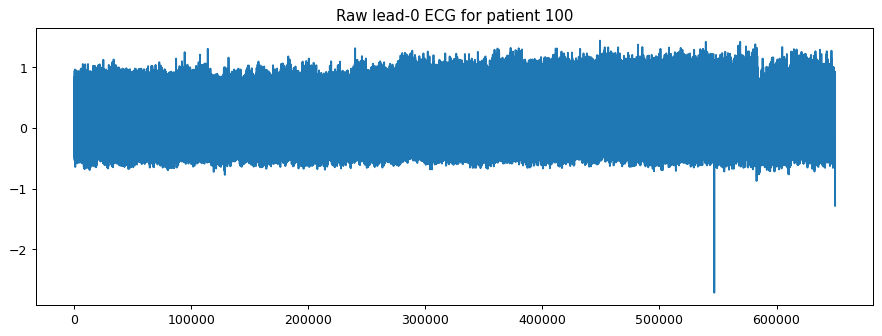

Signal of patient 100 extracted
Signal of patient 101 extracted
Signal of patient 102 extracted
Signal of patient 103 extracted
Signal of patient 104 extracted
Signal of patient 105 extracted
Signal of patient 106 extracted
Signal of patient 107 extracted
Signal of patient 108 extracted
Signal of patient 109 extracted
Signal of patient 111 extracted
Signal of patient 112 extracted
Signal of patient 113 extracted
Signal of patient 114 extracted
Signal of patient 115 extracted
Signal of patient 116 extracted
Signal of patient 117 extracted
Signal of patient 118 extracted
Signal of patient 119 extracted
Signal of patient 121 extracted
Signal of patient 122 extracted
Signal of patient 123 extracted
Signal of patient 124 extracted
Signal of patient 200 extracted
Signal of patient 201 extracted
Signal of patient 202 extracted
Signal of patient 203 extracted
Signal of patient 205 extracted
Signal of patient 207 extracted
Signal of patient 208 extracted
Signal of patient 209 extracted
Signal o

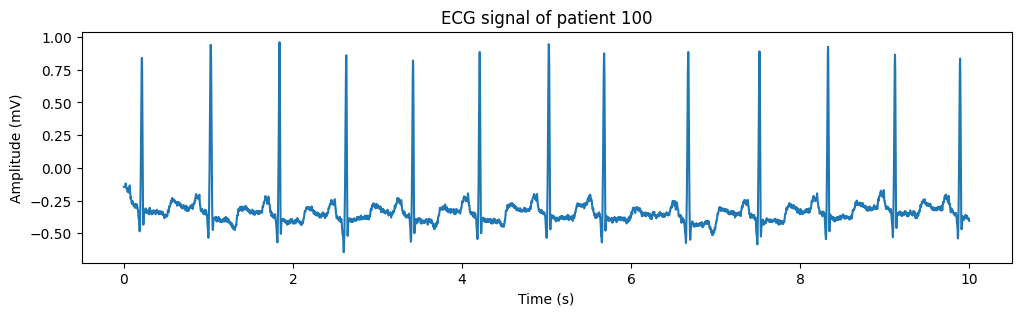

{'fs': 360, 'sig_len': 650000, 'n_sig': 2, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV'], 'sig_name': ['MLII', 'V5'], 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal'], 'resolution': 2048}


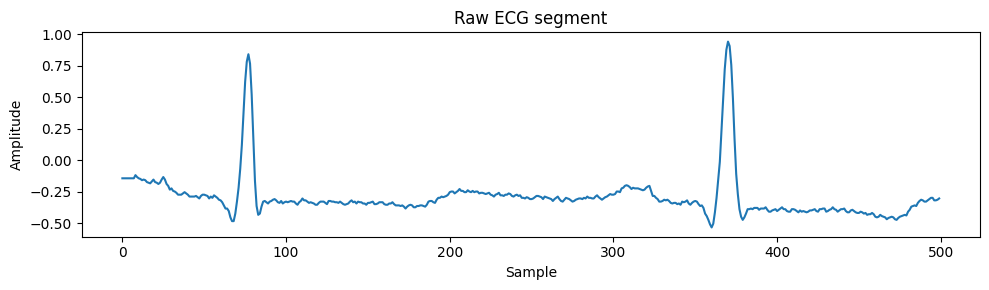

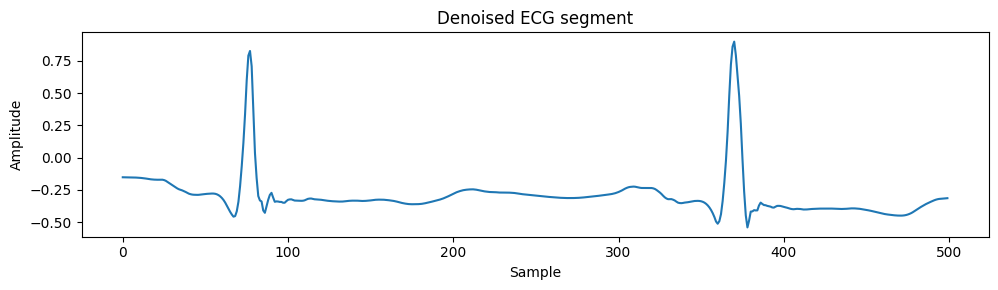

First R locations: [  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]
First R classes: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']
Total annotations: 2274


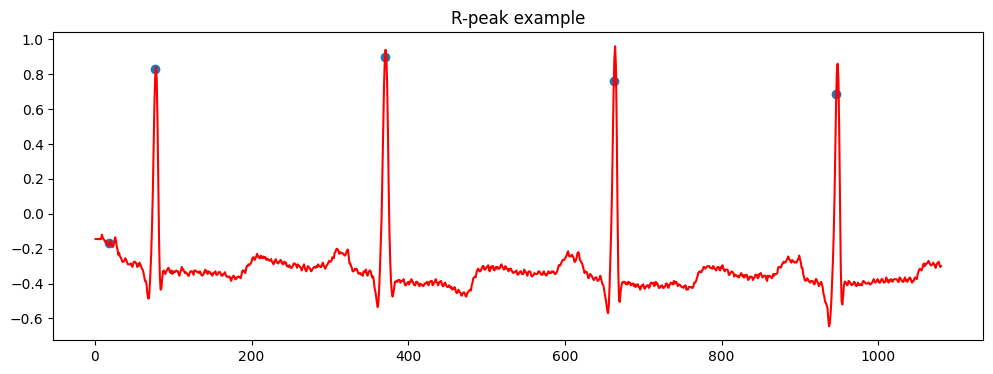

(300,)
(300,)
(300,)


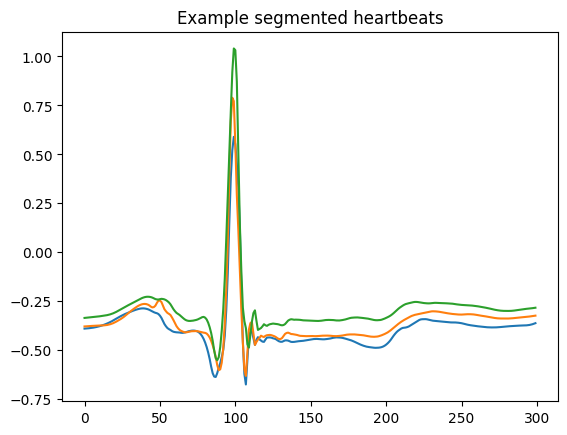

Saved figure: /content/drive/MyDrive/ecg_model/results/figures/Denoised_and_segmented_ECG.png


In [4]:
# ==========================================================
# B1 — Basic recording IDs
# ==========================================================
patient_ids = wfdb.get_record_list("mitdb")
print("Number of records:", len(patient_ids))
print(patient_ids)

# ==========================================================
# B2 — Load ECG signals and info
# ==========================================================
def get_ecg_signals(patient_ids, data_root=DATA_ROOT):
    lead0 = {}
    lead1 = {}

    for pid in patient_ids:
        signals, info = wfdb.io.rdsamp(osj(data_root, str(pid)))
        lead0[str(pid)] = signals[:, 0]
        lead1[str(pid)] = signals[:, 1]
        print(f"Signal of patient {pid} extracted")

    return lead0, lead1


def get_ecg_info(patient_id, data_root=DATA_ROOT):
    _, info = wfdb.io.rdsamp(osj(data_root, str(patient_id)))
    info["resolution"] = 2 ** 11
    return info

# ==========================================================
# B3 — Example: load one patient and visualise
# ==========================================================
lead0 = {}
lead1 = {}

patient_id = "100"
signals, info = wfdb.io.rdsamp(osj(DATA_ROOT, patient_id))
lead0[patient_id] = signals[:, 0]
lead1[patient_id] = signals[:, 1]

print(type(lead0[patient_id]))
print(lead0[patient_id].shape)
print(info)

plt.figure(figsize=(12, 4), dpi=90)
plt.plot(lead0[patient_id])
plt.title(f"Raw lead-0 ECG for patient {patient_id}")
save_current_plot("raw_ecg_patient_100.png")
plt.show()

# ==========================================================
# B4 — Plot signal for chosen time range
# FIXED: MIT-BIH is 360 Hz, not 350 Hz
# ==========================================================
lead0_all, lead1_all = get_ecg_signals(patient_ids)

patient_id = "100"
starting_time = 0
ending_time = 10
fs = 360

starting_signal_point = starting_time * fs
ending_signal_point = ending_time * fs

x = np.arange(starting_time, ending_time, 1 / fs)
signal = lead0_all[patient_id][starting_signal_point:ending_signal_point]

plt.figure(figsize=(12, 3), dpi=100)
plt.plot(x, signal)
plt.title(f"ECG signal of patient {patient_id}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
save_current_plot("ecg_signal_10s_patient_100.png")
plt.show()

ecg_info = get_ecg_info(patient_id)
print(ecg_info)

# ==========================================================
# B5 — Wavelet denoising
# ==========================================================
def denoise(data):
    """
    Wavelet-based ECG denoising using db5 decomposition.
    Returns a reconstructed denoised 1D signal.
    """
    coeffs = pywt.wavedec(data=data, wavelet="db5", level=9)
    cA9, cD9, cD8, cD7, cD6, cD5, cD4, cD3, cD2, cD1 = coeffs

    threshold = (np.median(np.abs(cD1)) / 0.6745) * np.sqrt(2 * np.log(len(cD1)))

    cD1.fill(0)
    cD2.fill(0)

    for i in range(1, len(coeffs) - 2):
        coeffs[i] = pywt.threshold(coeffs[i], threshold)

    rdata = pywt.waverec(coeffs=coeffs, wavelet="db5")
    return rdata

# ==========================================================
# B6 — Example denoising plot
# ==========================================================
record_path_100 = os.path.join(PROJECT_PATH, "100")
record = wfdb.rdrecord(record_path_100, channel_names=["MLII"])
data = record.p_signal.flatten()

plt.figure(figsize=(10, 3))
plt.plot(data[0:500])
plt.title("Raw ECG segment")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.tight_layout()
save_current_plot("raw_ecg_segment.png")
plt.show()

rdata = denoise(data=data)

plt.figure(figsize=(10, 3))
plt.plot(rdata[0:500])
plt.title("Denoised ECG segment")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.tight_layout()
save_current_plot("denoised_ecg_segment.png")
plt.show()

# ==========================================================
# B7 — R-peak extraction from annotations
# ==========================================================
annotation = wfdb.rdann(record_path_100, "atr")
Rlocation = annotation.sample
Rclass = annotation.symbol

print("First R locations:", Rlocation[:20])
print("First R classes:", Rclass[:20])
print("Total annotations:", len(Rclass))

# ==========================================================
# B8 — R-peak visualisation
# ==========================================================
x = np.arange(1, 1081)

n_peak = 5
r_peak_x = [Rlocation[i] for i in range(n_peak)]
r_peak_y = [rdata[Rlocation[i]] for i in range(n_peak)]

plt.figure(figsize=(12, 4))
plt.plot(x, data[:1080], color='red')
plt.scatter(r_peak_x, r_peak_y)
plt.title("R-peak example")
save_current_plot("r_peak_example.png")
plt.show()

# ==========================================================
# B9 — Heartbeat segmentation example
# ==========================================================
plt.figure(figsize=(10, 4))
for i in np.arange(100, 103):
    x_train_seg = rdata[Rlocation[i] - PRE_R:Rlocation[i] + POST_R]
    print(x_train_seg.shape)
    plt.plot(x_train_seg)

plt.title("Example segmented heartbeats")
save_current_plot("segmented_heartbeat_examples.png")
plt.show()

# ==========================================================
# B10 — Complete preprocessing figure
# ==========================================================
fig = plt.figure(figsize=(10, 9), dpi=300)
x = np.arange(1, 1081)

plt.subplot(3, 1, 1)
plt.plot(x / 360, data[:1080], color='red')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Raw ECG signal')

plt.subplot(3, 1, 2)
plt.plot(x / 360, rdata[:1080], color='red')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Denoised ECG signal')

plt.subplot(3, 1, 3)
n_peak = 5
r_peak_x = [Rlocation[i] for i in range(n_peak)]
r_peak_y = [rdata[Rlocation[i]] for i in range(n_peak)]
plt.plot(x, rdata[:1080], color='red')
plt.scatter(r_peak_x, r_peak_y)

plt.axvline(x=Rlocation[2], color='k', linestyle=':')
plt.axvline(x=Rlocation[2] - PRE_R, color='k', linestyle='--')
plt.axvline(x=Rlocation[2] + POST_R, color='k', linestyle='--')

plt.xlabel('# Sample')
plt.ylabel('Voltage (mV)')
plt.title('Segmentation using 3rd R-peak')

plt.subplots_adjust(hspace=0.4)
savefig_drive(fig, "Denoised_and_segmented_ECG.png")
plt.show()

# **C — Dataset Construction**

In [5]:
# ==========================================================
# C1 — Canonical 15-class and AAMI 5-class mappings
# ==========================================================
ECG_CLASS_SET_15 = ['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', '/', 'f', 'Q']

SYMBOL_TO_LABEL15 = {
    'N': 0,
    'L': 1,
    'R': 2,
    'e': 3,
    'j': 4,
    'A': 5,
    'a': 6,
    'J': 7,
    'S': 8,
    'V': 9,
    'E': 10,
    'F': 11,
    '/': 12,
    'f': 13,
    'Q': 14
}

AAMI_SYMBOL_TO_LABEL5 = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2,
    'F': 3,
    '/': 4, 'f': 4, 'Q': 4
}

def map_to_label15(symbol):
    return SYMBOL_TO_LABEL15.get(symbol, None)

def map_to_aami(symbol):
    return AAMI_SYMBOL_TO_LABEL5.get(symbol, None)

def is_valid_aami_symbol(symbol):
    return symbol in SYMBOL_TO_LABEL15 and symbol in AAMI_SYMBOL_TO_LABEL5

# ==========================================================
# C2 — Lead selection helper
# Islam-style single-lead processing
# ==========================================================
NUMBER_SET = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

def choose_single_lead(record_id):
    _, info = wfdb.io.rdsamp(osj(PROJECT_PATH, record_id))
    channels = info["sig_name"]

    if "MLII" in channels:
        return "MLII"
    return channels[0]

# ==========================================================
# C3 — Dataset construction
# Keeps Islam-style beat-level segmentation
# Adds record IDs for diagnostics only
# ==========================================================
def get_dataset_for_record(record_id, X_data, Y15_data, Y5_data, record_ids):
    lead_name = choose_single_lead(record_id)
    print(f"{record_id}: using channel {lead_name}")

    record = wfdb.rdrecord(
        os.path.join(PROJECT_PATH, record_id),
        channel_names=[lead_name]
    )
    data = record.p_signal.flatten()
    rdata = denoise(data)

    annotation = wfdb.rdann(os.path.join(PROJECT_PATH, record_id), "atr")
    r_locations = annotation.sample
    r_classes = annotation.symbol

    start = 2
    end = 3
    i = start
    j = len(r_classes) - end

    while i < j:
        beat_symbol = r_classes[i]

        if not is_valid_aami_symbol(beat_symbol):
            i += 1
            continue

        label_15 = map_to_label15(beat_symbol)
        label_5 = map_to_aami(beat_symbol)

        if label_15 is None or label_5 is None:
            i += 1
            continue

        left = r_locations[i] - PRE_R
        right = r_locations[i] + POST_R

        if left >= 0 and right <= len(rdata):
            segment = rdata[left:right]

            if len(segment) == SEG_LEN:
                segment = segment.astype(np.float32)
                segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)

                X_data.append(segment)
                Y15_data.append(int(label_15))
                Y5_data.append(int(label_5))
                record_ids.append(str(record_id))
        i += 1

    return X_data, Y15_data, Y5_data, record_ids


def load_data():
    data_set = []
    label15_set = []
    label5_set = []
    record_set = []

    for record_id in NUMBER_SET:
        print(f"Loading record {record_id} ...")
        data_set, label15_set, label5_set, record_set = get_dataset_for_record(
            record_id,
            data_set,
            label15_set,
            label5_set,
            record_set
        )

    X = np.asarray(data_set, dtype=np.float32).reshape(-1, SEG_LEN)
    Y15 = np.asarray(label15_set, dtype=np.int64).reshape(-1)
    Y5 = np.asarray(label5_set, dtype=np.int64).reshape(-1)
    record_ids = np.asarray(record_set, dtype=str)

    print("X shape:", X.shape)
    print("Y15 shape:", Y15.shape)
    print("Y5 shape:", Y5.shape)
    print("record_ids shape:", record_ids.shape)

    return X, Y15, Y5, record_ids

# ==========================================================
# C4 — Load canonical dataset
# ==========================================================
X_all, Y15_all, Y5_all, record_ids_all = load_data()

X_all = np.asarray(X_all, dtype=np.float32)
Y15_all = np.asarray(Y15_all, dtype=np.int64)
Y5_all = np.asarray(Y5_all, dtype=np.int64)
record_ids_all = np.asarray(record_ids_all, dtype=str)

print("15-class distribution:", Counter(Y15_all))
print("5-class distribution :", Counter(Y5_all))
print("Unique records:", len(np.unique(record_ids_all)))

# ==========================================================
# C5 — Dataset diagnostics
# ==========================================================
feature_cols = [f"x_{i}" for i in range(SEG_LEN)]

df_beats_5 = pd.DataFrame(X_all, columns=feature_cols)
df_beats_5["label_5"] = Y5_all.astype(np.int64)
df_beats_5["record_id"] = record_ids_all.astype(str)

df_beats_15 = pd.DataFrame(X_all, columns=feature_cols)
df_beats_15["label_15"] = Y15_all.astype(np.int64)
df_beats_15["record_id"] = record_ids_all.astype(str)

print("df_beats_5 shape:", df_beats_5.shape)
print("df_beats_15 shape:", df_beats_15.shape)

dataset_counts_15 = pd.DataFrame(
    Counter(Y15_all).items(),
    columns=["Class15", "Count"]
).sort_values("Class15")

dataset_counts_5 = pd.DataFrame(
    Counter(Y5_all).items(),
    columns=["Class5", "Count"]
).sort_values("Class5")

dataset_counts_15.to_csv(os.path.join(METRIC_DIR, "dataset_counts_15.csv"), index=False)
dataset_counts_5.to_csv(os.path.join(METRIC_DIR, "dataset_counts_5.csv"), index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dataset_counts_5["Class5"].astype(str), dataset_counts_5["Count"])
ax.set_xlabel("5-class label")
ax.set_ylabel("Count")
ax.set_title("Full 5-Class Dataset Distribution")
plt.tight_layout()
savefig_drive(fig, "full_5class_distribution.png")

# ==========================================================
# C6 — AAMI symbol audit
# ==========================================================
all_symbols_seen = []

for record_id in NUMBER_SET:
    ann = wfdb.rdann(os.path.join(PROJECT_PATH, record_id), "atr")
    all_symbols_seen.extend(ann.symbol)

all_symbols_seen = pd.Series(all_symbols_seen, dtype=str)
symbol_counts = all_symbols_seen.value_counts().sort_index()

symbol_audit_df = pd.DataFrame({
    "Symbol": symbol_counts.index,
    "Count": symbol_counts.values,
    "IncludedInStudy": [is_valid_aami_symbol(sym) for sym in symbol_counts.index],
    "Label15": [map_to_label15(sym) if is_valid_aami_symbol(sym) else None for sym in symbol_counts.index],
    "Label5": [map_to_aami(sym) if is_valid_aami_symbol(sym) else None for sym in symbol_counts.index],
})

symbol_audit_path = os.path.join(METRIC_DIR, "symbol_audit_mitbih.csv")
symbol_audit_df.to_csv(symbol_audit_path, index=False)

print(symbol_audit_df)
print(f"Saved symbol audit to: {symbol_audit_path}")

# ==========================================================
# C7 — Plot 15 heartbeat types
# ==========================================================
df_X = pd.DataFrame(X_all)
df_Y = pd.DataFrame(Y15_all)
df_Y.rename(columns={0: SEG_LEN}, inplace=True)
df = pd.concat([df_X, df_Y], axis=1)

def plot_random_beat(type_idx, num):
    ecgClassName = [
        'Normal (N)', 'Left bundle br. bl. (L)', 'Right bundle br. bl. (R)',
        'Atrial escape (e)', 'Nodal jun. esc. (j)', 'Atrial premature (A)',
        'Aberrated atrial prem. (a)', 'Nodal jun. pre. (J)',
        'Supraventricular prem. (S)', 'Premature ventr. (V)',
        'Ventricular escape (E)', 'Fusion of ve. & no. (F)',
        'Paced (/)', 'Fusion of pa. & no. (f)', 'Unclassifiable (Q)'
    ]

    df_0 = df.loc[df[SEG_LEN] == type_idx].drop(columns=[SEG_LEN])

    if df_0.shape[0] == 0:
        plt.title(f"No beats for class {type_idx}")
        return

    rng = np.random.default_rng(SEED)
    if num <= df_0.shape[0]:
        random_beat_number = rng.integers(0, df_0.shape[0], size=num).tolist()
    else:
        print(f"Warning: class {type_idx} has only {df_0.shape[0]} beats, plotting all")
        random_beat_number = list(np.arange(0, df_0.shape[0]))

    for i in random_beat_number:
        ecg_beat = df_0.iloc[i]
        plt.plot(ecg_beat.values)

    plt.title(ecgClassName[type_idx])

fig = plt.figure(figsize=(16, 7), dpi=400)
fig.tight_layout(pad=15.0)

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.4)
    plot_random_beat(type_idx=i, num=10)

savefig_drive(fig, "all_heartbeats.png")

Loading record 100 ...
100: using channel MLII
Loading record 101 ...
101: using channel MLII
Loading record 102 ...
102: using channel V5
Loading record 103 ...
103: using channel MLII
Loading record 104 ...
104: using channel V5
Loading record 105 ...
105: using channel MLII
Loading record 106 ...
106: using channel MLII
Loading record 107 ...
107: using channel MLII
Loading record 108 ...
108: using channel MLII
Loading record 109 ...
109: using channel MLII
Loading record 111 ...
111: using channel MLII
Loading record 112 ...
112: using channel MLII
Loading record 113 ...
113: using channel MLII
Loading record 114 ...
114: using channel MLII
Loading record 115 ...
115: using channel MLII
Loading record 116 ...
116: using channel MLII
Loading record 117 ...
117: using channel MLII
Loading record 118 ...
118: using channel MLII
Loading record 119 ...
119: using channel MLII
Loading record 121 ...
121: using channel MLII
Loading record 122 ...
122: using channel MLII
Loading record 12

# **D — Dataset Splitting & Balancing**

Raw split shapes:
x_train_raw: (69955, 300)
x_val      : (17489, 300)
x_test     : (21861, 300)

Training distribution:
0    57902
1     1776
2     4626
3      514
4     5137
Name: count, dtype: int64

Validation distribution:
0    14476
1      444
2     1157
3      128
4     1284
Name: count, dtype: int64

Test distribution:
0    18094
1      555
2     1446
3      160
4     1606
Name: count, dtype: int64
Saved validation set to: /content/drive/MyDrive/ecg_model/val_data.pkl
Saved test set to      : /content/drive/MyDrive/ecg_model/test_data.pkl
Imbalanced training distribution:
label_5
0    57902
1     1776
2     4626
3      514
4     5137
Name: count, dtype: int64


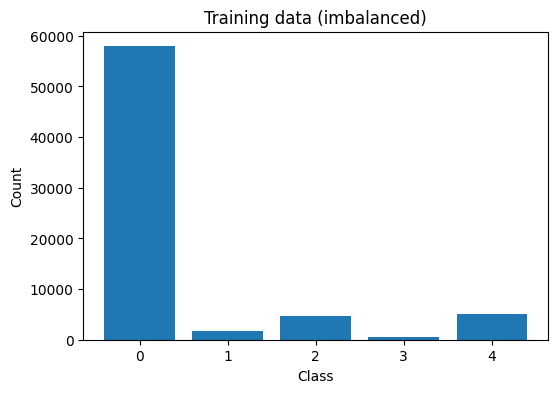

Minority training counts before SMOTE:
1    1776
2    4626
3     514
4    5137
Name: count, dtype: int64
Balanced training distribution:
label_5
0    50000
1    50000
2    50000
3    50000
4    50000
Name: count, dtype: int64
Saved balanced training data to: /content/drive/MyDrive/ecg_model/train_data_SMOTE.pkl
Saved figure: /content/drive/MyDrive/ecg_model/results/figures/Class_balancing.png
X_train: (250000, 300, 1) Y_train: (250000,)
X_val  : (17489, 300, 1) Y_val  : (17489,)
X_test : (21861, 300, 1) Y_test : (21861,)


In [6]:
# ==========================================================
# D1 — Beat-level split
# NOTE:
# - This is NOT patient-wise
# - Beats from same record can appear across splits
# - This matches the Islam-style pipeline you asked for
# ==========================================================
ecg_data = np.asarray(X_all, dtype=np.float32)
ecg_label = np.asarray(Y5_all, dtype=np.int64).reshape(-1)
record_id_array = np.asarray(record_ids_all, dtype=str)

# First split: train+temp vs test
x_train_full, x_test, y_train_full, y_test, rec_train_full, rec_test = train_test_split(
    ecg_data,
    ecg_label,
    record_id_array,
    test_size=0.20,
    random_state=104,
    shuffle=True,
    stratify=ecg_label
)

# Second split: train vs validation
x_train_raw, x_val, y_train_raw, y_val, rec_train_raw, rec_val = train_test_split(
    x_train_full,
    y_train_full,
    rec_train_full,
    test_size=0.20,
    random_state=104,
    shuffle=True,
    stratify=y_train_full
)

print("Raw split shapes:")
print("x_train_raw:", x_train_raw.shape)
print("x_val      :", x_val.shape)
print("x_test     :", x_test.shape)

print("\nTraining distribution:")
print(pd.Series(y_train_raw).value_counts().sort_index())
print("\nValidation distribution:")
print(pd.Series(y_val).value_counts().sort_index())
print("\nTest distribution:")
print(pd.Series(y_test).value_counts().sort_index())

# ==========================================================
# D2 — Save untouched validation and test sets
# ==========================================================
val_data = pd.DataFrame(x_val, columns=[f"x_{i}" for i in range(SEG_LEN)])
val_data["label_5"] = y_val.astype(np.int64)
val_data["record_id"] = rec_val.astype(str)

test_data = pd.DataFrame(x_test, columns=[f"x_{i}" for i in range(SEG_LEN)])
test_data["label_5"] = y_test.astype(np.int64)
test_data["record_id"] = rec_test.astype(str)

val_path = os.path.join(MODEL_DIR, "val_data.pkl")
test_path = os.path.join(MODEL_DIR, "test_data.pkl")

val_data.to_pickle(val_path)
test_data.to_pickle(test_path)

print("Saved validation set to:", val_path)
print("Saved test set to      :", test_path)

# ==========================================================
# D3 — Training distribution before balancing
# ==========================================================
train_data_raw = pd.DataFrame(x_train_raw, columns=[f"x_{i}" for i in range(SEG_LEN)])
train_data_raw["label_5"] = y_train_raw.astype(np.int64)

class_data_train_raw = train_data_raw["label_5"].value_counts().sort_index()
print("Imbalanced training distribution:")
print(class_data_train_raw)

plt.figure(figsize=(6, 4))
plt.bar(class_data_train_raw.index.astype(str), class_data_train_raw.values)
plt.title("Training data (imbalanced)")
plt.xlabel("Class")
plt.ylabel("Count")
save_current_plot("training_distribution_imbalanced.png")
plt.show()

# ==========================================================
# D4 — Balance TRAIN ONLY
# Islam-style balancing:
# - Class 0 downsample to 50000
# - Classes 1,2,3,4 oversample to 50000 using SMOTE
# IMPORTANT:
# - only train is balanced
# - val/test remain untouched
# ==========================================================
train_majority = train_data_raw.loc[train_data_raw["label_5"] == 0]
train_minority = train_data_raw.loc[train_data_raw["label_5"] != 0]

if len(train_majority) < 50000:
    raise RuntimeError(f"Class 0 has only {len(train_majority)} samples; cannot downsample to 50000.")

train_majority_resampled = train_majority.sample(n=50000, random_state=SEED)
train_majority_resampled = train_majority_resampled.to_numpy()

train_minority_arr = train_minority.to_numpy()
X_4cl = train_minority_arr[:, :-1].astype(np.float32)
y_4cl = train_minority_arr[:, -1].astype(np.int64)

minority_counts = pd.Series(y_4cl).value_counts().sort_index()
print("Minority training counts before SMOTE:")
print(minority_counts)

strategy = {}
for cls in [1, 2, 3, 4]:
    cls_count = int(minority_counts.get(cls, 0))
    if cls_count == 0:
        raise RuntimeError(f"Training split has zero samples for class {cls}; SMOTE cannot run.")
    strategy[cls] = 50000

oversample = SMOTE(sampling_strategy=strategy, random_state=SEED)
X_smote, y_smote = oversample.fit_resample(X_4cl, y_4cl)

train_minority_resampled = np.hstack((X_smote, y_smote.reshape(-1, 1)))

train_data_resampled = np.vstack((train_majority_resampled, train_minority_resampled))
np.random.shuffle(train_data_resampled)

train_data_bal = pd.DataFrame(train_data_resampled, columns=[f"x_{i}" for i in range(SEG_LEN)] + ["label_5"])

print("Balanced training distribution:")
print(train_data_bal["label_5"].astype(np.int64).value_counts().sort_index())

# ==========================================================
# D5 — Save balanced training set
# ==========================================================
train_bal_path = os.path.join(MODEL_DIR, "train_data_SMOTE.pkl")
train_data_bal.to_pickle(train_bal_path)

print("Saved balanced training data to:", train_bal_path)

# ==========================================================
# D6 — Before/after balancing plot
# ==========================================================
before_counts = train_data_raw["label_5"].value_counts().sort_index()
after_counts = train_data_bal["label_5"].astype(np.int64).value_counts().sort_index()

fig = plt.figure(figsize=(8, 4), dpi=300)

plt.subplot(1, 2, 1)
plt.bar(['N', 'S', 'V', 'F', 'Q'], [before_counts.get(i, 0) for i in range(5)])
plt.ylim(0, max(after_counts.values) * 1.05)
plt.title('Training data, imbalanced')

plt.subplot(1, 2, 2)
plt.bar(['N', 'S', 'V', 'F', 'Q'], [after_counts.get(i, 0) for i in range(5)])
plt.ylim(0, max(after_counts.values) * 1.05)
plt.title('Balanced by SMOTE')

plt.tight_layout()
savefig_drive(fig, "Class_balancing.png")

# ==========================================================
# D7 — Final arrays for training / validation / testing
# ==========================================================
X_train = train_data_bal.iloc[:, :SEG_LEN].to_numpy(dtype=np.float32).reshape(-1, SEG_LEN, 1)
Y_train = train_data_bal.iloc[:, SEG_LEN].to_numpy(dtype=np.int64)

X_val = np.asarray(x_val, dtype=np.float32).reshape(-1, SEG_LEN, 1)
Y_val = np.asarray(y_val, dtype=np.int64).reshape(-1)

X_test = np.asarray(x_test, dtype=np.float32).reshape(-1, SEG_LEN, 1)
Y_test = np.asarray(y_test, dtype=np.int64).reshape(-1)

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val  :", X_val.shape, "Y_val  :", Y_val.shape)
print("X_test :", X_test.shape, "Y_test :", Y_test.shape)

split_dist_df = pd.DataFrame({
    "Train": pd.Series(y_train_raw).value_counts().sort_index(),
    "Validation": pd.Series(y_val).value_counts().sort_index(),
    "Test": pd.Series(y_test).value_counts().sort_index()
}).fillna(0).astype(int)

split_dist_df.index = CLASS_NAMES_SHORT
split_dist_df.to_csv(os.path.join(METRIC_DIR, "split_class_distribution.csv"))

fig, ax = plt.subplots(figsize=(8, 5))
split_dist_df.plot(kind="bar", ax=ax)
ax.set_title("Class Distribution Across Splits")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
savefig_drive(fig, "split_class_distribution.png")

# **E — Model Architecture & Training**

In [7]:
# ==========================================================
# E1 — Attention blocks
# FIXED:
# - valid custom layers
# - explicit get_config for model save/load
# ==========================================================
class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, filters, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.ratio = ratio

    def build(self, input_shape):
        hidden_units = max(1, self.filters // self.ratio)

        self.shared_layer_one = tf.keras.layers.Dense(
            hidden_units,
            activation="relu",
            kernel_initializer="he_normal",
            use_bias=True,
            bias_initializer="zeros"
        )
        self.shared_layer_two = tf.keras.layers.Dense(
            self.filters,
            kernel_initializer="he_normal",
            use_bias=True,
            bias_initializer="zeros"
        )

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=1)
        avg_pool = self.shared_layer_one(avg_pool)
        avg_pool = self.shared_layer_two(avg_pool)

        max_pool = tf.reduce_max(inputs, axis=1)
        max_pool = self.shared_layer_one(max_pool)
        max_pool = self.shared_layer_two(max_pool)

        attention = avg_pool + max_pool
        attention = tf.nn.sigmoid(attention)
        attention = tf.reshape(attention, (-1, 1, self.filters))

        return inputs * attention

    def get_config(self):
        config = super().get_config()
        config.update({"filters": self.filters, "ratio": self.ratio})
        return config


class SpatialAttention1D(tf.keras.layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv = tf.keras.layers.Conv1D(
            filters=1,
            kernel_size=self.kernel_size,
            strides=1,
            padding="same",
            activation="sigmoid",
            kernel_initializer="he_normal",
            use_bias=False
        )

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        attention = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(attention)
        return inputs * attention

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

# ==========================================================
# E2 — CNN-LSTM with attention
# IMPORTANT:
# - includes explicit logits layer for calibration
# ==========================================================
def build_model():
    inputs = tf.keras.layers.Input(shape=(SEG_LEN, 1), name="ecg_input")

    x = tf.keras.layers.Conv1D(16, 21, padding="same", activation="relu", name="conv1")(inputs)
    x = ChannelAttention(16, 8, name="ca1")(x)
    x = tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding="same", name="pool1")(x)

    x = tf.keras.layers.Conv1D(32, 23, padding="same", activation="relu", name="conv2")(x)
    x = ChannelAttention(32, 8, name="ca2")(x)
    x = tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding="same", name="pool2")(x)

    x = tf.keras.layers.Conv1D(64, 25, padding="same", activation="relu", name="conv3")(x)
    x = ChannelAttention(64, 8, name="ca3")(x)
    x = tf.keras.layers.AvgPool1D(pool_size=3, strides=2, padding="same", name="pool3")(x)

    x = tf.keras.layers.Conv1D(128, 27, padding="same", activation="relu", name="conv4")(x)
    x = ChannelAttention(128, 8, name="ca4")(x)
    x = SpatialAttention1D(kernel_size=7, name="sa4")(x)

    x = tf.keras.layers.LSTM(64, return_sequences=True, name="lstm1")(x)
    x = tf.keras.layers.Dropout(0.2, name="dropout1")(x)
    x = tf.keras.layers.LSTM(32, return_sequences=True, name="lstm2")(x)

    x = tf.keras.layers.Flatten(name="flatten")(x)
    x = tf.keras.layers.Dense(128, activation="relu", name="embedding_dense")(x)
    x = tf.keras.layers.Dropout(0.2, name="dropout2")(x)

    logits = tf.keras.layers.Dense(5, activation=None, name="logits")(x)
    outputs = tf.keras.layers.Activation("softmax", name="classifier")(logits)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name="cnn_lstm_attention_ecg")


def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return model


def is_canonical_model(model):
    required_layers = {
        "ecg_input", "conv1", "conv2", "conv3", "conv4",
        "ca1", "ca2", "ca3", "ca4", "sa4",
        "lstm1", "lstm2", "embedding_dense", "logits", "classifier"
    }
    present = {layer.name for layer in model.layers}
    return required_layers.issubset(present)

# ==========================================================
# E3 — Training controls
# ==========================================================
FORCE_RETRAIN = True
TRAIN_EPOCHS = 30
TRAIN_BATCH_SIZE = 128
LEARNING_RATE = 1e-3

HISTORY_CSV = "training_history_islam_style_attention.csv"
TRAINING_META_JSON = "training_meta_islam_style_attention.json"

HISTORY_PATH = os.path.join(METRIC_DIR, HISTORY_CSV)
TRAINING_META_PATH = os.path.join(METRIC_DIR, TRAINING_META_JSON)

print("Training controls:")
print("FORCE_RETRAIN:", FORCE_RETRAIN)
print("TRAIN_EPOCHS:", TRAIN_EPOCHS)
print("TRAIN_BATCH_SIZE:", TRAIN_BATCH_SIZE)
print("LEARNING_RATE:", LEARNING_RATE)

# ==========================================================
# E4 — Validation metrics callback
# ==========================================================
class ValidationMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, x_val, y_val, batch_size=256):
        super().__init__()
        self.x_val = x_val
        self.y_val = y_val
        self.batch_size = batch_size

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        val_probs = self.model.predict(self.x_val, batch_size=self.batch_size, verbose=0)
        val_pred = np.argmax(val_probs, axis=1)

        val_macro_f1 = f1_score(self.y_val, val_pred, average="macro", zero_division=0)
        val_macro_precision = precision_score(self.y_val, val_pred, average="macro", zero_division=0)
        val_macro_recall = recall_score(self.y_val, val_pred, average="macro", zero_division=0)

        per_class_recalls = recall_score(
            self.y_val,
            val_pred,
            average=None,
            labels=np.arange(5),
            zero_division=0
        )

        minority_recall_min = float(np.min(per_class_recalls[1:]))

        logs["val_macro_f1"] = float(val_macro_f1)
        logs["val_macro_precision"] = float(val_macro_precision)
        logs["val_macro_recall"] = float(val_macro_recall)
        logs["val_minority_recall_min"] = minority_recall_min

        print(
            f"\nEpoch {epoch + 1}: "
            f"val_macro_f1 = {val_macro_f1:.6f} | "
            f"val_macro_precision = {val_macro_precision:.6f} | "
            f"val_macro_recall = {val_macro_recall:.6f} | "
            f"val_minority_recall_min = {minority_recall_min:.6f}"
        )

# ==========================================================
# E5 — Build / load / train
# IMPORTANT:
# - trains on BALANCED training set
# - validates on untouched validation set
# - no validation_split used
# ==========================================================
custom_objects = {
    "ChannelAttention": ChannelAttention,
    "SpatialAttention1D": SpatialAttention1D
}

history = None

if os.path.exists(MODEL_PATH) and not FORCE_RETRAIN:
    print("Loading existing final model:", MODEL_PATH)
    model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects)
    model = compile_model(model, learning_rate=LEARNING_RATE)
else:
    print("Training canonical model...")
    model = build_model()
    model = compile_model(model, learning_rate=LEARNING_RATE)

    logdir = os.path.join(
        MODEL_DIR,
        "logs",
        datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    )

    tensorboard_callback = tf.keras.callbacks.TensorBoard(
        log_dir=logdir,
        histogram_freq=0
    )

    csv_logger = tf.keras.callbacks.CSVLogger(HISTORY_PATH, append=False)

    val_metrics_cb = ValidationMetricsCallback(
        x_val=X_val,
        y_val=Y_val,
        batch_size=256
    )

    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        save_weights_only=True,
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
        verbose=1
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_macro_f1",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )

    history = model.fit(
        X_train,
        Y_train,
        epochs=TRAIN_EPOCHS,
        batch_size=TRAIN_BATCH_SIZE,
        validation_data=(X_val, Y_val),
        callbacks=[
            val_metrics_cb,
            checkpoint_cb,
            early_stopping,
            reduce_lr,
            csv_logger,
            tensorboard_callback
        ],
        verbose=1
    )

    if os.path.exists(CHECKPOINT_PATH):
        model.load_weights(CHECKPOINT_PATH)
        print("Reloaded best checkpoint weights based on val_macro_f1.")

    model.save(MODEL_PATH)
    print("Saved final model to:", MODEL_PATH)

    with open(TRAINING_META_PATH, "w") as f:
        json.dump({
            "seed": int(SEED),
            "epochs_requested": int(TRAIN_EPOCHS),
            "batch_size": int(TRAIN_BATCH_SIZE),
            "learning_rate": float(LEARNING_RATE),
            "model_path": MODEL_PATH,
            "checkpoint_path": CHECKPOINT_PATH,
            "history_path": HISTORY_PATH
        }, f, indent=2)

assert is_canonical_model(model), "Loaded/trained model is not the canonical architecture."

print("Canonical model ready.")
print("Model name:", model.name)
model.summary()

# ==========================================================
# E6 — Training curves
# ==========================================================
if history is not None:
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(HISTORY_PATH, index=False)

    if "accuracy" in history.history and "val_accuracy" in history.history:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(history.history["accuracy"], label="Train accuracy")
        ax.plot(history.history["val_accuracy"], label="Validation accuracy")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.set_title("Training and Validation Accuracy")
        ax.legend()
        plt.tight_layout()
        savefig_drive(fig, "training_validation_accuracy.png")

    if "loss" in history.history and "val_loss" in history.history:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(history.history["loss"], label="Train loss")
        ax.plot(history.history["val_loss"], label="Validation loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title("Training and Validation Loss")
        ax.legend()
        plt.tight_layout()
        savefig_drive(fig, "training_validation_loss.png")

    if "val_macro_f1" in history.history:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(history.history["val_macro_f1"], label="Validation macro-F1")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Macro-F1")
        ax.set_title("Validation Macro-F1")
        ax.legend()
        plt.tight_layout()
        savefig_drive(fig, "training_validation_macro_f1.png")

    if "val_minority_recall_min" in history.history:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(history.history["val_minority_recall_min"], label="Validation min minority recall")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Recall")
        ax.set_title("Validation Minimum Minority-Class Recall")
        ax.legend()
        plt.tight_layout()
        savefig_drive(fig, "training_validation_minority_recall.png")
else:
    print("Loaded final saved model — no new training history generated.")

# ==========================================================
# E7 — Post-training evaluation
# ==========================================================
val_probs_post = model.predict(X_val, batch_size=256, verbose=0)
val_preds_post = np.argmax(val_probs_post, axis=1)

test_probs_post = model.predict(X_test, batch_size=256, verbose=0)
test_preds_post = np.argmax(test_probs_post, axis=1)

val_acc_post = accuracy_score(Y_val, val_preds_post)
val_macro_precision_post = precision_score(Y_val, val_preds_post, average="macro", zero_division=0)
val_macro_recall_post = recall_score(Y_val, val_preds_post, average="macro", zero_division=0)
val_macro_f1_post = f1_score(Y_val, val_preds_post, average="macro", zero_division=0)

test_acc_post = accuracy_score(Y_test, test_preds_post)
test_macro_precision_post = precision_score(Y_test, test_preds_post, average="macro", zero_division=0)
test_macro_recall_post = recall_score(Y_test, test_preds_post, average="macro", zero_division=0)
test_macro_f1_post = f1_score(Y_test, test_preds_post, average="macro", zero_division=0)

val_recalls_post = recall_score(Y_val, val_preds_post, average=None, labels=np.arange(5), zero_division=0)
test_recalls_post = recall_score(Y_test, test_preds_post, average=None, labels=np.arange(5), zero_division=0)

quality_gate_df = pd.DataFrame([{
    "ValAccuracy": val_acc_post,
    "ValMacroPrecision": val_macro_precision_post,
    "ValMacroRecall": val_macro_recall_post,
    "ValMacroF1": val_macro_f1_post,
    "ValRecall_N": val_recalls_post[0],
    "ValRecall_S": val_recalls_post[1],
    "ValRecall_V": val_recalls_post[2],
    "ValRecall_F": val_recalls_post[3],
    "ValRecall_Q": val_recalls_post[4],
    "TestAccuracy": test_acc_post,
    "TestMacroPrecision": test_macro_precision_post,
    "TestMacroRecall": test_macro_recall_post,
    "TestMacroF1": test_macro_f1_post,
    "TestRecall_N": test_recalls_post[0],
    "TestRecall_S": test_recalls_post[1],
    "TestRecall_V": test_recalls_post[2],
    "TestRecall_F": test_recalls_post[3],
    "TestRecall_Q": test_recalls_post[4]
}])

quality_gate_path = os.path.join(METRIC_DIR, "post_training_quality_gate.csv")
quality_gate_df.to_csv(quality_gate_path, index=False)

print("===== POST-TRAINING GATE =====")
print(quality_gate_df)

print("\nValidation classification report:")
print(classification_report(Y_val, val_preds_post, target_names=CLASS_NAMES_SHORT, zero_division=0))

print("\nTest classification report:")
print(classification_report(Y_test, test_preds_post, target_names=CLASS_NAMES_SHORT, zero_division=0))

per_class_df = per_class_metrics_dataframe(Y_test, test_preds_post, class_names=CLASS_NAMES_SHORT)
per_class_path = os.path.join(METRIC_DIR, "test_per_class_metrics.csv")
per_class_df.to_csv(per_class_path, index=False)

cm = confusion_matrix(Y_test, test_preds_post)
cm_path = os.path.join(METRIC_DIR, "test_confusion_matrix.csv")
pd.DataFrame(cm).to_csv(cm_path, index=False)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest')
ax.set_title("Confusion Matrix (Test)")
plt.colorbar(im)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
savefig_drive(fig, "test_confusion_matrix.png")

print("Saved quality gate to:", quality_gate_path)
print("Saved per-class metrics to:", per_class_path)
print("Saved confusion matrix to:", cm_path)

val_report_df = pd.DataFrame(
    classification_report(
        Y_val,
        val_preds_post,
        target_names=CLASS_NAMES_SHORT,
        zero_division=0,
        output_dict=True
    )
).transpose()
val_report_df.to_csv(os.path.join(METRIC_DIR, "validation_classification_report.csv"))

test_report_df = pd.DataFrame(
    classification_report(
        Y_test,
        test_preds_post,
        target_names=CLASS_NAMES_SHORT,
        zero_division=0,
        output_dict=True
    )
).transpose()
test_report_df.to_csv(os.path.join(METRIC_DIR, "test_classification_report.csv"))

print("Saved validation and test classification reports.")

Training controls:
FORCE_RETRAIN: True
TRAIN_EPOCHS: 30
TRAIN_BATCH_SIZE: 128
LEARNING_RATE: 0.001
Training canonical model...
Epoch 1/30
 843/1954 ━━━━━━━━━━━━━━━━━━━━ 8:20 450ms/step - accuracy: 0.7584 - loss: 0.6059

KeyboardInterrupt: 

# **F — Calibration (Temperature Scaling + ECE)**

In [ ]:
# ==========================================================
# F1 — Calibration helpers
# ==========================================================
from scipy.optimize import minimize
from tensorflow.keras.models import Model

def softmax_np(logits):
    logits = np.asarray(logits, dtype=np.float64)
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def temperature_nll(T, logits, labels):
    T = max(float(T[0]), 1e-6)
    probs = softmax_np(logits / T)
    nll = -np.log(probs[np.arange(len(labels)), labels] + 1e-12)
    return float(np.mean(nll))

# ==========================================================
# F2 — Split validation into:
# 1) temperature-fit subset
# 2) conformal-calibration subset
# 3) calibration-holdout subset
# IMPORTANT:
# - all come only from validation
# - test remains untouched
# ==========================================================
X_val_temp, X_val_rest, y_val_temp, y_val_rest = train_test_split(
    X_val,
    Y_val,
    test_size=0.67,
    random_state=SEED,
    shuffle=True,
    stratify=Y_val
)

X_val_conf, X_val_hold, y_val_conf, y_val_hold = train_test_split(
    X_val_rest,
    y_val_rest,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
    stratify=y_val_rest
)

print("Temperature-fit set :", X_val_temp.shape, y_val_temp.shape)
print("Conformal-cal set   :", X_val_conf.shape, y_val_conf.shape)
print("Holdout-calib set   :", X_val_hold.shape, y_val_hold.shape)

print("\nTemp-fit distribution:")
print(pd.Series(y_val_temp).value_counts().sort_index())

print("\nConformal-cal distribution:")
print(pd.Series(y_val_conf).value_counts().sort_index())

print("\nHoldout-calib distribution:")
print(pd.Series(y_val_hold).value_counts().sort_index())

# ==========================================================
# F3 — True logits model
# ==========================================================
_ = model.predict(X_val[:1], verbose=0)

logits_model = Model(inputs=model.inputs, outputs=model.get_layer("logits").output)

def get_logits(x):
    x = np.asarray(x, dtype=np.float32)
    return logits_model.predict(x, batch_size=256, verbose=0)

# ==========================================================
# F4 — Fit temperature on validation subset only
# ==========================================================
labels_temp = flatten_labels(y_val_temp)
logits_temp = get_logits(X_val_temp)

opt = minimize(
    temperature_nll,
    x0=[1.0],
    args=(logits_temp, labels_temp),
    bounds=[(0.05, 10.0)],
    method="L-BFGS-B"
)

T_star = float(opt.x[0])
print("Optimal temperature:", T_star)

# ==========================================================
# F5 — Calibrated probability function
# ==========================================================
def predict_proba_uncalibrated(x):
    return model.predict(np.asarray(x, dtype=np.float32), batch_size=256, verbose=0)

def predict_proba_calibrated(x):
    logits = get_logits(x)
    return softmax_np(logits / T_star)

# ==========================================================
# F6 — Check calibration on validation holdout
# ==========================================================
labels_hold = flatten_labels(y_val_hold)

probs_hold_uncal = predict_proba_uncalibrated(X_val_hold)
probs_hold_cal = predict_proba_calibrated(X_val_hold)

ece_hold_uncal = compute_ece(probs_hold_uncal, labels_hold)
ece_hold_cal = compute_ece(probs_hold_cal, labels_hold)

brier_hold_uncal = macro_brier_score(labels_hold, probs_hold_uncal, num_classes=5)
brier_hold_cal = macro_brier_score(labels_hold, probs_hold_cal, num_classes=5)

nll_hold_uncal = float(log_loss(labels_hold, probs_hold_uncal))
nll_hold_cal = float(log_loss(labels_hold, probs_hold_cal))

acc_hold_uncal = float(np.mean(np.argmax(probs_hold_uncal, axis=1) == labels_hold))
acc_hold_cal = float(np.mean(np.argmax(probs_hold_cal, axis=1) == labels_hold))

print("===== HOLDOUT VALIDATION CALIBRATION CHECK =====")
print("ECE before calibration:", ece_hold_uncal)
print("ECE after calibration :", ece_hold_cal)
print("Brier before calibration:", brier_hold_uncal)
print("Brier after calibration :", brier_hold_cal)
print("NLL before calibration:", nll_hold_uncal)
print("NLL after calibration :", nll_hold_cal)
print("Accuracy before calibration:", acc_hold_uncal)
print("Accuracy after calibration :", acc_hold_cal)

# ==========================================================
# F7 — Final calibration evaluation on TEST
# IMPORTANT:
# - temperature fitted using validation subset only
# - test still untouched for fitting
# ==========================================================
labels_test = flatten_labels(Y_test)

probs_test_uncal = predict_proba_uncalibrated(X_test)
probs_test_cal = predict_proba_calibrated(X_test)

ece_test_uncal = compute_ece(probs_test_uncal, labels_test)
ece_test_cal = compute_ece(probs_test_cal, labels_test)

brier_test_uncal = macro_brier_score(labels_test, probs_test_uncal, num_classes=5)
brier_test_cal = macro_brier_score(labels_test, probs_test_cal, num_classes=5)

nll_test_uncal = float(log_loss(labels_test, probs_test_uncal))
nll_test_cal = float(log_loss(labels_test, probs_test_cal))

acc_test_uncal = float(np.mean(np.argmax(probs_test_uncal, axis=1) == labels_test))
acc_test_cal = float(np.mean(np.argmax(probs_test_cal, axis=1) == labels_test))

print("===== TEST CALIBRATION RESULTS =====")
print("ECE before calibration:", ece_test_uncal)
print("ECE after calibration :", ece_test_cal)
print("Brier before calibration:", brier_test_uncal)
print("Brier after calibration :", brier_test_cal)
print("NLL before calibration:", nll_test_uncal)
print("NLL after calibration :", nll_test_cal)
print("Accuracy before calibration:", acc_test_uncal)
print("Accuracy after calibration :", acc_test_cal)

# ==========================================================
# F8 — Reliability plots
# ==========================================================
conf_uncal_curve, acc_uncal_curve = reliability_curve_points(probs_test_uncal, labels_test, n_bins=10)
conf_cal_curve, acc_cal_curve = reliability_curve_points(probs_test_cal, labels_test, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(conf_uncal_curve, acc_uncal_curve, marker="o", label="Uncalibrated")
ax.plot(conf_cal_curve, acc_cal_curve, marker="o", label="Calibrated")
ax.plot([0, 1], [0, 1], "--", label="Perfect calibration")
ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title("Calibration Comparison (Test)")
ax.legend()
plt.tight_layout()
savefig_drive(fig, "calibration_comparison_test.png")

# ==========================================================
# F9 — Save calibration artefacts
# ==========================================================
calibration_metrics = pd.DataFrame({
    "Metric": [
        "Temperature",
        "Holdout_ECE_before",
        "Holdout_ECE_after",
        "Holdout_Brier_before",
        "Holdout_Brier_after",
        "Holdout_NLL_before",
        "Holdout_NLL_after",
        "Holdout_Accuracy_before",
        "Holdout_Accuracy_after",
        "Test_ECE_before",
        "Test_ECE_after",
        "Test_Brier_before",
        "Test_Brier_after",
        "Test_NLL_before",
        "Test_NLL_after",
        "Test_Accuracy_before",
        "Test_Accuracy_after"
    ],
    "Value": [
        T_star,
        ece_hold_uncal,
        ece_hold_cal,
        brier_hold_uncal,
        brier_hold_cal,
        nll_hold_uncal,
        nll_hold_cal,
        acc_hold_uncal,
        acc_hold_cal,
        ece_test_uncal,
        ece_test_cal,
        brier_test_uncal,
        brier_test_cal,
        nll_test_uncal,
        nll_test_cal,
        acc_test_uncal,
        acc_test_cal
    ]
})

calibration_metrics_path = os.path.join(METRIC_DIR, "calibration_metrics.csv")
calibration_metrics.to_csv(calibration_metrics_path, index=False)

temperature_path = os.path.join(METRIC_DIR, "temperature_scaling_value.json")
with open(temperature_path, "w") as f:
    json.dump({"T_star": float(T_star)}, f, indent=2)

print(calibration_metrics)
print("Saved calibration metrics to:", calibration_metrics_path)
print("Saved temperature to:", temperature_path)

# ==========================================================
# F10 — Example calibrated inference output helper
# ==========================================================
def make_prediction_output(prob_vector, class_names=CLASS_NAMES_SHORT):
    prob_vector = np.asarray(prob_vector, dtype=np.float64).reshape(-1)
    pred_idx = int(np.argmax(prob_vector))
    sorted_idx = np.argsort(prob_vector)[::-1]

    top1 = float(prob_vector[sorted_idx[0]])
    top2 = float(prob_vector[sorted_idx[1]]) if len(sorted_idx) > 1 else 0.0
    margin = top1 - top2

    entropy = float(-np.sum(prob_vector * np.log(prob_vector + 1e-12)))
    entropy_norm = float(entropy / np.log(len(prob_vector)))

    risk_score = float((1.0 - top1) + entropy_norm * 0.5 - margin * 0.25)

    if top1 >= 0.80 and entropy_norm < 0.40:
        decision_risk_category = "Low"
    elif top1 >= 0.60 and entropy_norm < 0.65:
        decision_risk_category = "Medium"
    else:
        decision_risk_category = "High"

    return {
        "prediction": class_names[pred_idx],
        "confidence": top1,
        "risk_level": decision_risk_category,
        "conformal_set": [class_names[pred_idx]],  # placeholder until conformal stage
        "details": {
            "probabilities": prob_vector.tolist(),
            "prediction_margin": margin,
            "entropy": entropy,
            "entropy_normalised": entropy_norm,
            "confidence_level": confidence_band(top1),
            "class_index": pred_idx,
            "risk_score": risk_score,
            "flags": [],
            "top_k": [
                {"class_index": int(i), "class_name": class_names[int(i)], "probability": float(prob_vector[int(i)])}
                for i in sorted_idx[:3]
            ],
            "prototype_indices": []
        },
        "explanations": {
            "importance_map": None,
            "prototype_labels": [],
            "prototype_label_names": [],
            "prototype_similarities": []
        },
        "clinical_risk": decision_risk_category
    }

example_probs = predict_proba_calibrated(X_test[:1])[0]
example_output = make_prediction_output(example_probs)

print(json.dumps(example_output, indent=2))

# **G — Uncertainty Modelling (Conformal Prediction)**

In [ ]:
# ==========================================================
# G — Uncertainty Modelling (Conformal Prediction)
# ==========================================================

alpha = 0.10  # target 90% coverage

labels_conf = flatten_labels(y_val_conf)
conf_probs = predict_proba_calibrated(X_val_conf)

conf_scores = 1.0 - conf_probs[np.arange(len(labels_conf)), labels_conf]

n_conf = len(conf_scores)
quantile_level = np.ceil((n_conf + 1) * (1 - alpha)) / n_conf
quantile_level = min(1.0, quantile_level)

qhat = np.quantile(conf_scores, quantile_level, method="higher")

print("Conformal threshold qhat:", qhat)
print("Quantile level used:", quantile_level)

def conformal_prediction_set(x):
    probs = predict_proba_calibrated(x)
    prediction_sets = []

    for p in probs:
        scores = 1.0 - p
        indices = np.where(scores <= qhat)[0]

        if len(indices) == 0:
            indices = np.array([np.argmax(p)])

        prediction_sets.append(indices)

    return prediction_sets

test_sets = conformal_prediction_set(X_test)
true_test = flatten_labels(Y_test)

covered = np.array([true_test[i] in test_sets[i] for i in range(len(true_test))], dtype=bool)
set_sizes = np.array([len(s) for s in test_sets])

conformal_by_class = pd.DataFrame({
    "TrueClass": true_test,
    "SetSize": set_sizes
})

summary = conformal_by_class.groupby("TrueClass")["SetSize"].mean().reset_index()
summary["TrueClass"] = summary["TrueClass"].map(lambda i: CLASS_NAMES_SHORT[int(i)])
summary.to_csv(os.path.join(METRIC_DIR, "conformal_set_size_by_class.csv"), index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary["TrueClass"], summary["SetSize"])
ax.set_xlabel("True class")
ax.set_ylabel("Mean conformal set size")
ax.set_title("Mean Conformal Set Size by True Class")
plt.tight_layout()
savefig_drive(fig, "conformal_set_size_by_class.png")

empirical_coverage = float(np.mean(covered))
mean_set_size = float(np.mean(set_sizes))
singleton_rate = float(np.mean(set_sizes == 1))
ambiguity_rate = float(np.mean(set_sizes > 1))

print("Empirical test coverage:", empirical_coverage)
print("Mean prediction set size:", mean_set_size)
print("Singleton rate:", singleton_rate)
print("Ambiguity rate:", ambiguity_rate)

conformal_metrics = pd.DataFrame({
    "Metric": ["EmpiricalCoverage", "MeanSetSize", "SingletonRate", "AmbiguityRate", "Qhat"],
    "Value": [empirical_coverage, mean_set_size, singleton_rate, ambiguity_rate, float(qhat)]
})
conformal_metrics.to_csv(os.path.join(METRIC_DIR, "conformal_metrics.csv"), index=False)

fig, ax = plt.subplots(figsize=(6, 4))
unique_sizes, counts = np.unique(set_sizes, return_counts=True)
ax.bar(unique_sizes.astype(str), counts)
ax.set_xlabel("Prediction set size")
ax.set_ylabel("Count")
ax.set_title("Distribution of Conformal Prediction Set Sizes")
plt.tight_layout()
savefig_drive(fig, "conformal_set_size_distribution.png")

# **H — Evaluation & Performance Analysis**

In [ ]:
# ==========================================================
# UNIFIED EVALUATION BLOCK — canonical dissertation version
# ==========================================================

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

Y_test_flat = flatten_labels(Y_test)

# ----------------------------------------------------------
# Baselines
# ----------------------------------------------------------
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

maj = DummyClassifier(strategy="most_frequent")
maj.fit(X_train_flat, Y_train)
maj_pred = maj.predict(X_test_flat)
maj_probs = maj.predict_proba(X_test_flat)

logreg = LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)
logreg.fit(X_train_flat, Y_train)
lr_pred = logreg.predict(X_test_flat)
lr_probs = logreg.predict_proba(X_test_flat)

def summarise_model(name, y_true, y_pred, probs):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "MacroPrecision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "MacroRecall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "MacroF1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "ECE": compute_ece(probs, y_true)
    }

# ----------------------------------------------------------
# CNN predictions
# ----------------------------------------------------------
probs_uncal = model.predict(X_test, batch_size=256, verbose=0)
preds_uncal = np.argmax(probs_uncal, axis=1)

probs_cal = predict_proba_calibrated(X_test)
preds_cal = np.argmax(probs_cal, axis=1)

test_correct = (preds_cal == Y_test_flat)
test_conf = np.max(probs_cal, axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(test_conf[test_correct], bins=20, alpha=0.7, label="Correct")
ax.hist(test_conf[~test_correct], bins=20, alpha=0.7, label="Incorrect")
ax.set_xlabel("Calibrated confidence")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution: Correct vs Incorrect")
ax.legend()
plt.tight_layout()
savefig_drive(fig, "confidence_hist_correct_vs_incorrect.png")

# ----------------------------------------------------------
# Classifier summary table
# ----------------------------------------------------------
classifier_metrics = pd.DataFrame([
    summarise_model("Majority", Y_test_flat, maj_pred, maj_probs),
    summarise_model("LogisticRegression", Y_test_flat, lr_pred, lr_probs),
    {
        "Model": "CNN-LSTM Uncalibrated",
        "Accuracy": accuracy_score(Y_test_flat, preds_uncal),
        "MacroPrecision": precision_score(Y_test_flat, preds_uncal, average="macro", zero_division=0),
        "MacroRecall": recall_score(Y_test_flat, preds_uncal, average="macro", zero_division=0),
        "MacroF1": f1_score(Y_test_flat, preds_uncal, average="macro", zero_division=0),
        "ECE": compute_ece(probs_uncal, Y_test_flat)
    },
    {
        "Model": "CNN-LSTM Calibrated",
        "Accuracy": accuracy_score(Y_test_flat, preds_cal),
        "MacroPrecision": precision_score(Y_test_flat, preds_cal, average="macro", zero_division=0),
        "MacroRecall": recall_score(Y_test_flat, preds_cal, average="macro", zero_division=0),
        "MacroF1": f1_score(Y_test_flat, preds_cal, average="macro", zero_division=0),
        "ECE": compute_ece(probs_cal, Y_test_flat)
    }
])

classifier_metrics["ROC_AUC_OVR"] = np.nan
classifier_metrics["Brier"] = np.nan
classifier_metrics["NLL"] = np.nan

classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Uncalibrated", "ROC_AUC_OVR"] = roc_auc_score(Y_test_flat, probs_uncal, multi_class="ovr")
classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Uncalibrated", "Brier"] = macro_brier_score(Y_test_flat, probs_uncal, num_classes=5)
classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Uncalibrated", "NLL"] = log_loss(Y_test_flat, probs_uncal)

classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Calibrated", "ROC_AUC_OVR"] = roc_auc_score(Y_test_flat, probs_cal, multi_class="ovr")
classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Calibrated", "Brier"] = macro_brier_score(Y_test_flat, probs_cal, num_classes=5)
classifier_metrics.loc[classifier_metrics["Model"] == "CNN-LSTM Calibrated", "NLL"] = log_loss(Y_test_flat, probs_cal)

classifier_metrics.to_csv(os.path.join(METRIC_DIR, "classifier_metrics_unified.csv"), index=False)
with open(os.path.join(TAB_DIR, "classifier_metrics_unified.tex"), "w") as f:
    f.write(classifier_metrics.to_latex(index=False, float_format="%.4f"))

print(classifier_metrics)

# ----------------------------------------------------------
# Per-class metrics on calibrated predictions
# ----------------------------------------------------------
per_class_df = per_class_metrics_dataframe(Y_test_flat, preds_cal, class_names=CLASS_NAMES_SHORT)
per_class_df.to_csv(os.path.join(METRIC_DIR, "per_class_metrics_calibrated.csv"), index=False)

with open(os.path.join(TAB_DIR, "per_class_metrics_calibrated.tex"), "w") as f:
    f.write(per_class_df.to_latex(index=False, float_format="%.4f"))

print(per_class_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(per_class_df["Class"], per_class_df["F1"])
ax.set_xlabel("Class")
ax.set_ylabel("F1")
ax.set_title("Per-Class F1 Scores (Calibrated CNN-LSTM)")
plt.tight_layout()
savefig_drive(fig, "per_class_f1_scores.png")

# ----------------------------------------------------------
# Confusion matrix
# ----------------------------------------------------------
cm = confusion_matrix(Y_test_flat, preds_cal, labels=np.arange(5))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_NAMES_SHORT,
    yticklabels=CLASS_NAMES_SHORT,
    ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Calibrated CNN-LSTM)")
plt.tight_layout()
savefig_drive(fig, "confusion_matrix_calibrated.png")

# **I — Explainability (Grad-CAM)**

In [ ]:
# ==========================================================
# Part I — Explainability: 1D Grad-CAM
# ==========================================================

_ = model.predict(X_test[:1], verbose=0)

GRADCAM_TARGET_LAYER = "conv4"

gradcam_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(GRADCAM_TARGET_LAYER).output,
        model.output
    ]
)

def gradcam_1d(signal, class_idx=None):
    signal = np.asarray(signal, dtype=np.float32)

    if signal.ndim == 1:
        signal = signal.reshape(1, 300, 1)
    elif signal.ndim == 2:
        signal = signal[np.newaxis, :, :]

    signal = tf.convert_to_tensor(signal)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = gradcam_model(signal, training=False)
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        class_score = predictions[:, class_idx]

    grads = tape.gradient(class_score, conv_outputs)
    if grads is None:
        raise RuntimeError("Grad-CAM gradient computation failed.")

    pooled_grads = tf.reduce_mean(grads, axis=1)[0]
    conv_outputs = conv_outputs[0]

    cam = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    cam = tf.nn.relu(cam).numpy()

    if np.max(cam) > 0:
        cam = cam / np.max(cam)

    cam_resized = np.interp(
        np.linspace(0, len(cam) - 1, 300),
        np.arange(len(cam)),
        cam
    )

    return cam_resized

def plot_ecg_gradcam(ecg, importance_map, title="ECG with 1D Grad-CAM", filename="gradcam_ecg_example.png"):
    ecg = np.asarray(ecg).flatten()
    importance_map = np.asarray(importance_map).flatten()

    if np.max(importance_map) > 0:
        importance_map = importance_map / np.max(importance_map)

    t = np.arange(len(ecg))
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.imshow(
        importance_map[np.newaxis, :],
        cmap="hot",
        aspect="auto",
        extent=[0, len(ecg), np.min(ecg), np.max(ecg)],
        alpha=0.5
    )
    ax.plot(t, ecg, color="black", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude")

    plt.tight_layout()
    savefig_drive(fig, filename)

sample = X_test[0].flatten()
cam = gradcam_1d(sample)
plot_ecg_gradcam(sample, cam, title="Example ECG with 1D Grad-CAM", filename="gradcam_ecg_example.png")

# **J — Prototype-Based Explanation**

In [ ]:
# ==========================================================
# Part J — Prototype retrieval (reproducible sampled bank)
# ==========================================================

from tensorflow.keras.models import Model
from sklearn.metrics.pairwise import cosine_similarity

embedding_model = Model(
    inputs=model.inputs,
    outputs=model.get_layer("embedding_dense").output
)

print("Embedding dimension:", embedding_model.output_shape)

PROTOTYPE_BANK_SIZE = 5000
rng = np.random.default_rng(SEED)

# Use REAL pre-SMOTE training beats for prototype explanations
X_train_real = np.asarray(x_train_raw, dtype=np.float32).reshape(-1, SEG_LEN, 1)
y_train_real = np.asarray(y_train_raw, dtype=np.int64).reshape(-1)

bank_size = min(PROTOTYPE_BANK_SIZE, len(X_train_real))
bank_indices = rng.choice(len(X_train_real), size=bank_size, replace=False)

X_bank = X_train_real[bank_indices]
y_bank = y_train_real[bank_indices]

print("Prototype bank size:", X_bank.shape)

def compute_embeddings(x):
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    emb = embedding_model(x, training=False).numpy()
    norm = np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8
    return emb / norm

emb_bank = compute_embeddings(X_bank)
print("Embedding bank shape:", emb_bank.shape)

def retrieve_topk(signal, k=3):
    signal = np.asarray(signal, dtype=np.float32)

    if signal.ndim == 1:
        signal = signal.reshape(1, 300, 1)
    elif signal.ndim == 2:
        signal = signal[np.newaxis, :, :]

    query_emb = compute_embeddings(signal)
    sim = cosine_similarity(query_emb, emb_bank)[0]
    idx = np.argsort(sim)[-k:][::-1]

    return {
        "indices": bank_indices[idx],
        "signals": X_bank[idx],
        "labels": y_bank[idx],
        "similarities": sim[idx]
    }

def plot_prototypes(query_signal, result, filename="prototype_retrieval_example.png"):
    k = len(result["signals"])
    fig = plt.figure(figsize=(10, 3 * (k + 1)))

    plt.subplot(k + 1, 1, 1)
    plt.plot(query_signal.flatten(), color="black")
    plt.title("Query ECG")
    plt.ylabel("Amplitude")

    for i in range(k):
        plt.subplot(k + 1, 1, i + 2)
        plt.plot(result["signals"][i].flatten())
        plt.title(
            f"Prototype {i+1} | label={CLASS_NAMES_SHORT[int(result['labels'][i])]} | "
            f"similarity={result['similarities'][i]:.4f}"
        )
        plt.ylabel("Amplitude")

    plt.xlabel("Sample")
    plt.tight_layout()
    savefig_drive(fig, filename)

sample = X_test[0].flatten()
retrieval = retrieve_topk(sample, k=3)
plot_prototypes(sample, retrieval, filename="prototype_retrieval_example.png")

# **K — Robustness Testing (Noise Stress)**

In [ ]:
# ==========================================================
# Part K — Robustness testing with performance + reliability metrics
# ==========================================================

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(SEED)

wfdb.dl_database("nstdb", dl_dir=os.path.join(DRIVE_DATA_ROOT, "nstdb"))

noise_types = {
    "baseline_wander": "bw",
    "muscle_artifact": "ma",
    "electrode_motion": "em"
}

noise_signals = {}
for name, record in noise_types.items():
    signal, _ = wfdb.rdsamp(record, pn_dir="nstdb")
    noise = signal[:, 0]
    noise = (noise - np.mean(noise)) / (np.std(noise) + 1e-8)
    noise_signals[name] = noise

print("Loaded NSTDB noises:", list(noise_signals.keys()))

def add_noise(signal, noise_segment, snr_db):
    signal = signal.flatten()
    noise_segment = noise_segment[:len(signal)]

    signal_rms = np.sqrt(np.mean(signal ** 2))
    noise_rms = np.sqrt(np.mean(noise_segment ** 2))

    factor = signal_rms / (noise_rms * (10 ** (snr_db / 20)))
    return signal + noise_segment * factor

def generate_noisy_dataset(X, noise_signal, snr_db):
    n = len(X)
    length = X.shape[1]
    max_start = len(noise_signal) - length

    X_noisy = []
    for i in range(n):
        start = np.random.randint(0, max_start)
        noise_segment = noise_signal[start:start + length]
        noisy = add_noise(X[i].squeeze(), noise_segment, snr_db)
        X_noisy.append(noisy)

    return np.array(X_noisy, dtype=np.float32)[..., None]

N_TEST = min(2000, len(X_test))
X_eval = X_test[:N_TEST]
y_eval = flatten_labels(Y_test[:N_TEST])

snr_levels = [24, 18, 12, 6, 0]
rows = []

for noise_name, noise_signal in noise_signals.items():
    print(f"\nTesting noise: {noise_name}")

    for snr in snr_levels:
        X_noisy = generate_noisy_dataset(X_eval, noise_signal, snr)

        probs = predict_proba_calibrated(X_noisy)
        preds = np.argmax(probs, axis=1)
        conf = np.max(probs, axis=1)

        pred_sets = conformal_prediction_set(X_noisy)
        set_sizes = np.array([len(s) for s in pred_sets])
        covered = np.array([y_eval[i] in pred_sets[i] for i in range(len(y_eval))], dtype=bool)

        accept_mask = (conf >= 0.60) & (set_sizes == 1)

        row = {
            "NoiseType": noise_name,
            "SNR_dB": snr,
            "Accuracy": accuracy_score(y_eval, preds),
            "MacroRecall": recall_score(y_eval, preds, average="macro", zero_division=0),
            "MacroF1": f1_score(y_eval, preds, average="macro", zero_division=0),
            "MeanConfidence": float(np.mean(conf)),
            "ECE": compute_ece(probs, y_eval),
            "EmpiricalCoverage": float(np.mean(covered)),
            "MeanSetSize": float(np.mean(set_sizes)),
            "DeferralRate": float(1.0 - np.mean(accept_mask)),
            "AcceptedAccuracy": float(np.mean(preds[accept_mask] == y_eval[accept_mask])) if np.any(accept_mask) else np.nan
        }

        rows.append(row)
        print(
            f"SNR {snr:>2} dB | "
            f"Acc {row['Accuracy']:.3f} | "
            f"MacroF1 {row['MacroF1']:.3f} | "
            f"ECE {row['ECE']:.4f} | "
            f"Deferral {row['DeferralRate']:.3f}"
        )

robustness_df = pd.DataFrame(rows)
robustness_df.to_csv(os.path.join(METRIC_DIR, "robustness_metrics_full.csv"), index=False)
with open(os.path.join(TAB_DIR, "robustness_metrics_full.tex"), "w") as f:
    f.write(robustness_df.to_latex(index=False, float_format="%.4f"))

print(robustness_df.head())

# ----------------------------------------------------------
# Accuracy vs SNR figure
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
for noise_name in robustness_df["NoiseType"].unique():
    sub = robustness_df[robustness_df["NoiseType"] == noise_name].sort_values("SNR_dB")
    ax.plot(sub["SNR_dB"], sub["Accuracy"], marker="o", label=noise_name)

ax.set_xlabel("Signal-to-Noise Ratio (dB)")
ax.set_ylabel("Accuracy")
ax.set_title("Robustness: Accuracy vs SNR")
ax.invert_xaxis()
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
savefig_drive(fig, "robustness_accuracy_vs_snr.png")

# ----------------------------------------------------------
# ECE vs SNR figure
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
for noise_name in robustness_df["NoiseType"].unique():
    sub = robustness_df[robustness_df["NoiseType"] == noise_name].sort_values("SNR_dB")
    ax.plot(sub["SNR_dB"], sub["ECE"], marker="o", label=noise_name)

ax.set_xlabel("Signal-to-Noise Ratio (dB)")
ax.set_ylabel("ECE")
ax.set_title("Robustness: Calibration Error vs SNR")
ax.invert_xaxis()
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
savefig_drive(fig, "robustness_ece_vs_snr.png")

# ----------------------------------------------------------
# Deferral rate vs SNR figure
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
for noise_name in robustness_df["NoiseType"].unique():
    sub = robustness_df[robustness_df["NoiseType"] == noise_name].sort_values("SNR_dB")
    ax.plot(sub["SNR_dB"], sub["DeferralRate"], marker="o", label=noise_name)

ax.set_xlabel("Signal-to-Noise Ratio (dB)")
ax.set_ylabel("Deferral rate")
ax.set_title("Robustness: Deferral Rate vs SNR")
ax.invert_xaxis()
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
savefig_drive(fig, "robustness_deferral_vs_snr.png")

# **L — Decision Layer (Accept / Defer)**

In [ ]:
# ==========================================================
# Decision layer: accept / defer + risk–coverage
# Rule: defer if calibrated confidence < 0.60 or set size > 1
# ==========================================================

Y_test_flat = flatten_labels(Y_test)

test_sets = conformal_prediction_set(X_test)
set_sizes = np.array([len(s) for s in test_sets])
covered = np.array([Y_test_flat[i] in test_sets[i] for i in range(len(Y_test_flat))], dtype=bool)

cal_conf = np.max(probs_cal, axis=1)
reliability_bands = np.array([confidence_band(c) for c in cal_conf])

accept_mask = (cal_conf >= 0.60) & (set_sizes == 1)
defer_mask = ~accept_mask

decision_class_df = pd.DataFrame({
    "TrueClass": Y_test_flat,
    "Decision": np.where(accept_mask, "Accept", "Defer")
})

decision_summary = pd.crosstab(decision_class_df["TrueClass"], decision_class_df["Decision"])
decision_summary.index = [CLASS_NAMES_SHORT[int(i)] for i in decision_summary.index]
decision_summary.to_csv(os.path.join(METRIC_DIR, "decision_by_true_class.csv"))

fig, ax = plt.subplots(figsize=(7, 5))
decision_summary.plot(kind="bar", stacked=True, ax=ax)
ax.set_xlabel("True class")
ax.set_ylabel("Count")
ax.set_title("Accept vs Defer by True Class")
plt.tight_layout()
savefig_drive(fig, "accept_vs_defer_by_true_class.png")

accepted_count = int(np.sum(accept_mask))
deferred_count = int(np.sum(defer_mask))

coverage = float(np.mean(accept_mask))
deferral_rate = float(np.mean(defer_mask))

accepted_accuracy = float(np.mean(preds_cal[accept_mask] == Y_test_flat[accept_mask])) if accepted_count > 0 else np.nan
accepted_error_rate = float(1.0 - accepted_accuracy) if accepted_count > 0 else np.nan
overall_error_rate = float(np.mean(preds_cal != Y_test_flat))

decision_df = pd.DataFrame({
    "TrueLabel": Y_test_flat,
    "PredLabel": preds_cal,
    "Confidence": cal_conf,
    "ReliabilityBand": reliability_bands,
    "SetSize": set_sizes,
    "Covered": covered,
    "Decision": np.where(accept_mask, "Accept", "Defer"),
    "Correct": (preds_cal == Y_test_flat).astype(int)
})
decision_df.to_csv(os.path.join(METRIC_DIR, "decision_level_predictions.csv"), index=False)

decision_metrics = pd.DataFrame([{
    "Coverage": coverage,
    "DeferralRate": deferral_rate,
    "AcceptedCount": accepted_count,
    "DeferredCount": deferred_count,
    "AcceptedAccuracy": accepted_accuracy,
    "AcceptedErrorRate": accepted_error_rate,
    "OverallErrorRate": overall_error_rate
}])
decision_metrics.to_csv(os.path.join(METRIC_DIR, "decision_metrics.csv"), index=False)

with open(os.path.join(TAB_DIR, "decision_metrics.tex"), "w") as f:
    f.write(decision_metrics.to_latex(index=False, float_format="%.4f"))

print(decision_metrics)

# ----------------------------------------------------------
# Risk–coverage curve
# ----------------------------------------------------------
thresholds = np.linspace(0.50, 0.99, 25)
risk_coverage_rows = []

for th in thresholds:
    mask = (cal_conf >= th) & (set_sizes == 1)
    cov = float(np.mean(mask))

    if np.sum(mask) > 0:
        acc = float(np.mean(preds_cal[mask] == Y_test_flat[mask]))
        risk = float(1.0 - acc)
    else:
        acc = np.nan
        risk = np.nan

    risk_coverage_rows.append({
        "Threshold": float(th),
        "Coverage": cov,
        "AcceptedAccuracy": acc,
        "AcceptedRisk": risk
    })

risk_coverage_df = pd.DataFrame(risk_coverage_rows)
risk_coverage_df.to_csv(os.path.join(METRIC_DIR, "risk_coverage_curve.csv"), index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(risk_coverage_df["Coverage"], risk_coverage_df["AcceptedRisk"], marker="o")
ax.set_xlabel("Coverage")
ax.set_ylabel("Risk (1 - accepted accuracy)")
ax.set_title("Risk–Coverage Curve")
plt.tight_layout()
savefig_drive(fig, "risk_coverage_curve.png")

# **M — External Validation (INCART)**

In [ ]:
# ==========================================================
# M — External Validation (INCART)
# STRICT:
# - no retraining
# - no temperature refit
# - no conformal refit
# uses frozen model + T_star + qhat
# ==========================================================

import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss
)

required_globals = [
    "SEG_LEN",
    "PRE_R",
    "POST_R",
    "CLASS_NAMES_SHORT",
    "denoise",
    "is_valid_aami_symbol",
    "map_to_aami",
    "flatten_labels",
    "predict_proba_calibrated",
    "conformal_prediction_set",
    "compute_ece",
    "macro_brier_score",
    "per_class_metrics_dataframe",
    "savefig_drive",
    "METRIC_DIR",
    "TAB_DIR",
    "T_star",
    "qhat"
]

missing_globals = [name for name in required_globals if name not in globals()]
if len(missing_globals) > 0:
    raise RuntimeError("INCART block missing prerequisites: " + ", ".join(missing_globals))

INCART_PATH = "/content/drive/MyDrive/ecg_datasets/incartdb"
os.makedirs(INCART_PATH, exist_ok=True)

INCART_ALL_RECORDS = [str(r) for r in wfdb.get_record_list("incartdb")]
INCART_MAX_RECORDS = None

if INCART_MAX_RECORDS is None:
    INCART_RECORDS = INCART_ALL_RECORDS
else:
    INCART_RECORDS = INCART_ALL_RECORDS[:int(INCART_MAX_RECORDS)]

def incart_record_is_cached(record_id, base_path):
    required_suffixes = [".dat", ".hea", ".atr"]
    return all(
        os.path.exists(os.path.join(base_path, f"{record_id}{suffix}"))
        for suffix in required_suffixes
    )

missing_records = [
    rid for rid in INCART_RECORDS
    if not incart_record_is_cached(rid, INCART_PATH)
]

if len(missing_records) == 0:
    print("INCART cache already complete.")
else:
    print(f"Missing INCART records: {len(missing_records)}")
    print("Downloading only missing INCART records...")
    wfdb.dl_database("incartdb", dl_dir=INCART_PATH, records=missing_records)
    print("INCART download completed.")

def choose_incart_single_lead(record_path):
    record = wfdb.rdrecord(record_path)
    sig_names = list(record.sig_name)

    if "II" in sig_names:
        return "II"
    elif "MLII" in sig_names:
        return "MLII"
    else:
        return sig_names[0]

def load_incart_dataset(record_ids, base_path):
    X_data = []
    Y5_data = []
    record_id_data = []
    per_record_rows = []

    for idx, record_id in enumerate(record_ids, start=1):
        print(f"[{idx}/{len(record_ids)}] Loading INCART record {record_id} ...")
        try:
            record_path = os.path.join(base_path, str(record_id))
            if not incart_record_is_cached(str(record_id), base_path):
                print(f"Skipping {record_id}: files not fully cached.")
                continue

            lead_name = choose_incart_single_lead(record_path)
            record = wfdb.rdrecord(record_path, channel_names=[lead_name])
            signal = record.p_signal.flatten().astype(np.float32)
            signal = denoise(signal)

            ann = wfdb.rdann(record_path, "atr")
            r_locs = np.asarray(ann.sample, dtype=np.int64)
            r_syms = list(ann.symbol)

            kept_beats = 0
            symbol_counter = Counter()

            for i, sym in enumerate(r_syms):
                if not is_valid_aami_symbol(sym):
                    continue

                label_5 = map_to_aami(sym)
                if label_5 is None:
                    continue

                left = int(r_locs[i] - PRE_R)
                right = int(r_locs[i] + POST_R)

                if left < 0 or right > len(signal):
                    continue

                segment = signal[left:right]

                if len(segment) != SEG_LEN:
                    continue

                segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)

                X_data.append(segment.astype(np.float32))
                Y5_data.append(int(label_5))
                record_id_data.append(str(record_id))

                kept_beats += 1
                symbol_counter[sym] += 1

            per_record_rows.append({
                "record_id": str(record_id),
                "lead_used": str(lead_name),
                "beats_kept": int(kept_beats),
                "symbols_kept": dict(symbol_counter)
            })

            print(f"    lead={lead_name} | beats_kept={kept_beats}")

        except Exception as e:
            print(f"Skipping INCART record {record_id} due to error: {e}")

    X = np.asarray(X_data, dtype=np.float32)
    Y = np.asarray(Y5_data, dtype=np.int64)
    record_ids_out = np.asarray(record_id_data, dtype=str)
    per_record_df = pd.DataFrame(per_record_rows)

    if len(X) == 0:
        raise RuntimeError("INCART loader produced zero usable beats.")

    return X, Y, record_ids_out, per_record_df

X_incart, Y_incart, incart_record_ids, incart_record_summary = load_incart_dataset(
    record_ids=INCART_RECORDS,
    base_path=INCART_PATH
)

X_incart = X_incart.reshape(-1, SEG_LEN, 1).astype(np.float32)
Y_incart_flat = flatten_labels(Y_incart)

incart_record_summary.to_csv(
    os.path.join(METRIC_DIR, "incart_record_loading_summary.csv"),
    index=False
)

probs_incart = predict_proba_calibrated(X_incart)
preds_incart = np.argmax(probs_incart, axis=1)
conf_incart = np.max(probs_incart, axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(conf_incart, bins=20)
ax.set_xlabel("Calibrated confidence")
ax.set_ylabel("Count")
ax.set_title("INCART Confidence Distribution")
plt.tight_layout()
savefig_drive(fig, "incart_confidence_distribution.png")

incart_sets = conformal_prediction_set(X_incart)
incart_set_sizes = np.asarray([len(s) for s in incart_sets], dtype=np.int64)

incart_covered = np.asarray([
    Y_incart_flat[i] in incart_sets[i]
    for i in range(len(Y_incart_flat))
], dtype=bool)

CONF_THRESHOLD = 0.60
accept_mask_incart = (conf_incart >= CONF_THRESHOLD) & (incart_set_sizes == 1)

incart_accuracy = float(accuracy_score(Y_incart_flat, preds_incart))
incart_macro_precision = float(precision_score(Y_incart_flat, preds_incart, average="macro", zero_division=0))
incart_macro_recall = float(recall_score(Y_incart_flat, preds_incart, average="macro", zero_division=0))
incart_macro_f1 = float(f1_score(Y_incart_flat, preds_incart, average="macro", zero_division=0))
incart_ece = float(compute_ece(probs_incart, Y_incart_flat))
incart_brier = float(macro_brier_score(Y_incart_flat, probs_incart, num_classes=5))
incart_nll = float(log_loss(Y_incart_flat, probs_incart))

incart_coverage = float(np.mean(incart_covered))
incart_mean_set_size = float(np.mean(incart_set_sizes))
incart_singleton_rate = float(np.mean(incart_set_sizes == 1))
incart_ambiguity_rate = float(np.mean(incart_set_sizes > 1))
incart_deferral = float(1.0 - np.mean(accept_mask_incart))

incart_accept_acc = (
    float(np.mean(preds_incart[accept_mask_incart] == Y_incart_flat[accept_mask_incart]))
    if np.any(accept_mask_incart) else np.nan
)

incart_metrics = pd.DataFrame([{
    "Dataset": "INCART",
    "RecordsSelected": int(len(INCART_RECORDS)),
    "RecordsWithUsableBeats": int(len(np.unique(incart_record_ids))),
    "TotalBeats": int(len(Y_incart_flat)),
    "Accuracy": incart_accuracy,
    "MacroPrecision": incart_macro_precision,
    "MacroRecall": incart_macro_recall,
    "MacroF1": incart_macro_f1,
    "ECE": incart_ece,
    "Brier": incart_brier,
    "NLL": incart_nll,
    "Coverage": incart_coverage,
    "MeanSetSize": incart_mean_set_size,
    "SingletonRate": incart_singleton_rate,
    "AmbiguityRate": incart_ambiguity_rate,
    "DeferralRate": incart_deferral,
    "AcceptedAccuracy": incart_accept_acc,
    "ConfidenceThreshold": float(CONF_THRESHOLD),
    "TemperatureFrozen": float(T_star),
    "QhatFrozen": float(qhat)
}])

incart_metrics.to_csv(
    os.path.join(METRIC_DIR, "incart_external_validation.csv"),
    index=False
)

with open(os.path.join(TAB_DIR, "incart_external_validation.tex"), "w") as f:
    f.write(incart_metrics.to_latex(index=False, float_format="%.4f"))

print("\n===== INCART EXTERNAL VALIDATION =====")
print(incart_metrics)

incart_per_class_df = per_class_metrics_dataframe(
    Y_incart_flat,
    preds_incart,
    class_names=CLASS_NAMES_SHORT
)
incart_per_class_df.to_csv(
    os.path.join(METRIC_DIR, "incart_per_class_metrics.csv"),
    index=False
)

cm = confusion_matrix(Y_incart_flat, preds_incart, labels=np.arange(5))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES_SHORT,
    yticklabels=CLASS_NAMES_SHORT,
    ax=ax
)
ax.set_title("INCART Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
savefig_drive(fig, "incart_confusion_matrix.png")

print("INCART external-validation block completed successfully.")

# **N — Inference System (Deployment Pipeline)**

In [ ]:
# ==========================================================
# N — Inference System (Deployment Pipeline)
# CORRECTED:
# - consistent risk logic
# - no conflicting Fusion risk flag
# - explicit structured inference object
# ==========================================================

from scipy.stats import entropy
import datetime
import numpy as np

CLASS_NAMES = [
    "Normal",
    "Supraventricular",
    "Ventricular",
    "Fusion",
    "Unknown"
]

RISK_MAP = {
    "Normal": "Low",
    "Supraventricular": "Moderate",
    "Ventricular": "High",
    "Fusion": "Moderate",
    "Unknown": "High"
}

def preprocess_ecg(ecg_segment, assume_preprocessed=False):
    ecg_segment = np.asarray(ecg_segment, dtype=np.float32).reshape(-1)

    if ecg_segment.shape[0] != SEG_LEN:
        raise ValueError(f"ECG segment must have length {SEG_LEN}")

    if not assume_preprocessed:
        ecg_segment = (ecg_segment - np.mean(ecg_segment)) / (np.std(ecg_segment) + 1e-8)

    return ecg_segment.reshape(1, SEG_LEN, 1)

def prediction_confidence(probabilities):
    probabilities = np.asarray(probabilities, dtype=np.float64).reshape(-1)
    probabilities = np.clip(probabilities, 1e-12, 1.0)
    probabilities = probabilities / np.sum(probabilities)

    max_prob = float(np.max(probabilities))
    sorted_probs = np.sort(probabilities)
    margin = float(sorted_probs[-1] - sorted_probs[-2])

    ent = float(entropy(probabilities))
    ent_norm = float(ent / np.log(len(probabilities)))

    return {
        "confidence_score": max_prob,
        "prediction_margin": margin,
        "entropy": ent,
        "entropy_normalised": ent_norm,
        "confidence_level": confidence_band(max_prob)
    }

def risk_indicator(class_name, confidence, conformal_size=None, confidence_threshold=0.60):
    base_risk = RISK_MAP.get(class_name, "Unknown")
    risk_level = base_risk
    flags = []

    if confidence < confidence_threshold:
        risk_level = "Uncertain"
        flags.append("low_confidence")

    if conformal_size is not None and conformal_size > 1:
        risk_level = "Ambiguous"
        flags.append("multiple_conformal_classes")

    risk_scale = {
        "Low": 1,
        "Moderate": 2,
        "High": 3,
        "Uncertain": 4,
        "Ambiguous": 5
    }

    return {
        "clinical_risk": base_risk,
        "risk_level": risk_level,
        "risk_score": int(risk_scale.get(risk_level, 0)),
        "flags": flags
    }

def simple_signal_quality(ecg_segment):
    ecg_segment = np.asarray(ecg_segment, dtype=np.float32).reshape(-1)

    std = float(np.std(ecg_segment))
    mean_abs = float(np.mean(np.abs(ecg_segment)))
    peak_to_peak = float(np.ptp(ecg_segment))

    if not np.isfinite(std) or not np.isfinite(mean_abs) or not np.isfinite(peak_to_peak):
        score = 0.0
    else:
        raw = 1.0 / (1.0 + std)
        score = float(np.clip(raw, 0.0, 1.0))

    if score >= 0.75:
        label = "Good"
    elif score >= 0.45:
        label = "Moderate"
    else:
        label = "Poor"

    return {
        "score": score,
        "label": label,
        "statistics": {
            "std": std,
            "mean_absolute_amplitude": mean_abs,
            "peak_to_peak": peak_to_peak
        }
    }

def predict_heartbeat(ecg_segment, return_gradcam=False, return_prototypes=False, top_k=3):
    x = preprocess_ecg(ecg_segment, assume_preprocessed=False)

    probs = predict_proba_calibrated(x)[0]
    probs = np.asarray(probs, dtype=np.float64).reshape(-1)

    predicted_class = int(np.argmax(probs))
    confidence = float(np.max(probs))

    topk_idx = np.argsort(probs)[-top_k:][::-1]
    top_k_predictions = [
        {
            "class_index": int(i),
            "class_name": CLASS_NAMES[int(i)],
            "probability": float(probs[int(i)])
        }
        for i in topk_idx
    ]

    result = {
        "class_index": int(predicted_class),
        "class_name": CLASS_NAMES[predicted_class],
        "confidence": confidence,
        "probabilities": probs.tolist(),
        "top_k": top_k_predictions
    }

    if return_gradcam:
        result["gradcam"] = gradcam_1d(x[0]).tolist()

    if return_prototypes:
        retrieval = retrieve_topk(x[0], k=top_k)
        prototype_label_indices = flatten_labels(retrieval["labels"]).astype(int)

        result["prototypes"] = {
            "indices": [int(i) for i in np.asarray(retrieval["indices"]).reshape(-1)],
            "label_indices": [int(i) for i in prototype_label_indices],
            "label_names": [CLASS_NAMES[int(i)] for i in prototype_label_indices],
            "similarities": [float(s) for s in np.asarray(retrieval["similarities"]).reshape(-1)]
        }

    return result

def ecg_inference(ecg_segment, include_nlg=True):
    ecg_segment = np.asarray(ecg_segment, dtype=np.float32).reshape(SEG_LEN)

    prediction = predict_heartbeat(
        ecg_segment,
        return_gradcam=True,
        return_prototypes=True,
        top_k=3
    )

    probs = np.asarray(prediction["probabilities"], dtype=np.float64).reshape(-1)
    conf_info = prediction_confidence(probs)

    x = preprocess_ecg(ecg_segment, assume_preprocessed=False)
    conformal_idx = conformal_prediction_set(x)[0]
    conformal_idx = [int(i) for i in np.asarray(conformal_idx).reshape(-1)]
    conformal_names = [CLASS_NAMES[i] for i in conformal_idx]

    risk = risk_indicator(
        prediction["class_name"],
        conf_info["confidence_score"],
        conformal_size=len(conformal_idx)
    )

    decision = (
        "Accept"
        if (conf_info["confidence_score"] >= 0.60 and len(conformal_names) == 1)
        else "Defer"
    )

    signal_quality = simple_signal_quality(ecg_segment)

    ui_flags = {
        "low_confidence": bool(conf_info["confidence_score"] < 0.60),
        "ambiguous": bool(len(conformal_names) > 1),
        "high_risk_class": bool(RISK_MAP.get(prediction["class_name"], "Unknown") == "High"),
        "poor_signal_quality": bool(signal_quality["label"] == "Poor")
    }
    ui_flags["requires_review"] = bool(
        ui_flags["low_confidence"] or
        ui_flags["ambiguous"] or
        ui_flags["high_risk_class"] or
        decision == "Defer"
    )

    result = {
        "prediction": prediction["class_name"],
        "confidence": float(conf_info["confidence_score"]),
        "risk_level": risk["risk_level"],
        "clinical_risk": risk["clinical_risk"],
        "conformal_set": conformal_names,
        "decision": decision,
        "signal_quality": {
            "score": float(signal_quality["score"]),
            "label": signal_quality["label"]
        },
        "ui_flags": ui_flags,
        "details": {
            "class_index": int(prediction["class_index"]),
            "probabilities": probs.tolist(),
            "prediction_margin": float(conf_info["prediction_margin"]),
            "entropy": float(conf_info["entropy"]),
            "entropy_normalised": float(conf_info["entropy_normalised"]),
            "confidence_level": conf_info["confidence_level"],
            "risk_score": int(risk["risk_score"]),
            "flags": list(risk["flags"]),
            "top_k": prediction["top_k"],
            "prototype_indices": prediction["prototypes"]["indices"]
        },
        "explanations": {
            "importance_map": prediction["gradcam"],
            "prototype_labels": prediction["prototypes"]["label_indices"],
            "prototype_label_names": prediction["prototypes"]["label_names"],
            "prototype_similarities": prediction["prototypes"]["similarities"]
        },
        "visualisation": {
            "gradcam_overlay": prediction["gradcam"],
            "confidence_band": conf_info["confidence_level"]
        },
        "meta": {
            "model_version": str(MODEL_NAME) if "MODEL_NAME" in globals() else "unknown_model",
            "weights_version": str(WEIGHTS_NAME) if "WEIGHTS_NAME" in globals() else "unknown_weights",
            "temperature": float(T_star) if "T_star" in globals() else None,
            "qhat": float(qhat) if "qhat" in globals() else None,
            "input_length": int(SEG_LEN),
            "generated_at_utc": datetime.datetime.utcnow().isoformat() + "Z"
        }
    }

    if include_nlg:
        if "generate_nlg" not in globals():
            raise RuntimeError(
                "generate_nlg(...) is not defined. Run the NLG block first, "
                "or call ecg_inference(..., include_nlg=False)."
            )

        nlg = generate_nlg(result)

        result["interpretation"] = {
            "summary": nlg["summary"],
            "patient_message": nlg["patient_text"],
            "clinician_message": nlg["clinician_text"],
            "reliability": conf_info["confidence_level"],
            "action": "Review" if ui_flags["requires_review"] else "Accept"
        }

        waveform_analysis = nlg.get("waveform_analysis", {})
        if isinstance(waveform_analysis, dict):
            result["visualisation"]["highlight_region"] = waveform_analysis.get("dominant_region", "QRS")

    return result

# **O — Natural Language Generation (NLG)**

In [ ]:
# ==========================================================
# O — Natural Language Generation (NLG)
# Generates:
#   - patient-facing explanation
#   - clinician-facing explanation
#   - short summary
# Uses the structured output of ecg_inference(...)
# ==========================================================

import numpy as np

# ----------------------------------------------------------
# Canonical names
# ----------------------------------------------------------
CLASS_NAMES_FULL = ["Normal", "Supraventricular", "Ventricular", "Fusion", "Unknown"]

# ----------------------------------------------------------
# Helper functions
# ----------------------------------------------------------
def confidence_phrase(band):
    return {
        "High": "high confidence",
        "Medium": "moderate confidence",
        "Low": "low confidence"
    }.get(str(band), "uncertain confidence")


def signal_quality_phrase(flags):
    """
    Infer a simple signal-quality phrasing from internal flags.
    In the current pipeline, flags mainly encode uncertainty /
    ambiguity states rather than explicit raw signal artefact
    measures, so wording must remain conservative.
    """
    flags = list(flags) if flags is not None else []

    if len(flags) == 0:
        return "acceptable"

    if "multiple_conformal_classes" in flags or "low_confidence" in flags:
        return "reduced"
    return "uncertain"


def is_ambiguous(conformal_set):
    conformal_set = list(conformal_set) if conformal_set is not None else []
    return len(conformal_set) > 1


# ----------------------------------------------------------
# Grad-CAM → approximate waveform-region interpretation
# NOTE:
# This is an approximate mapping of the 300-sample beat window
# into broad morphology regions, not a clinical delineation tool.
# ----------------------------------------------------------
def extract_waveform_features(importance_map):
    importance_map = np.asarray(importance_map, dtype=np.float32).reshape(-1)

    if importance_map.size == 0:
        return {
            "dominant_region": "QRS",
            "region_scores": {"P": 0.0, "QRS": 0.0, "T": 0.0},
            "notes": ["importance map unavailable"]
        }

    if importance_map.size != SEG_LEN:
        x_old = np.linspace(0, 1, importance_map.size)
        x_new = np.linspace(0, 1, SEG_LEN)
        importance_map = np.interp(x_new, x_old, importance_map)

    # Approximate heartbeat-region partition for a 300-sample beat
    # centred around the R peak:
    #   P-wave region   ≈ samples   0:90
    #   QRS region      ≈ samples  90:180
    #   T-wave region   ≈ samples 180:300
    region_slices = {
        "P": importance_map[0:90],
        "QRS": importance_map[90:180],
        "T": importance_map[180:300]
    }

    region_scores = {
        region: float(np.mean(values)) if len(values) > 0 else 0.0
        for region, values in region_slices.items()
    }

    dominant_region = max(region_scores, key=region_scores.get)

    notes = []
    if dominant_region == "P":
        notes.append("attention is concentrated before the main ventricular spike")
    elif dominant_region == "QRS":
        notes.append("attention is concentrated on the main ventricular depolarisation region")
    elif dominant_region == "T":
        notes.append("attention is concentrated after the main spike in the recovery region")

    ranked_regions = sorted(region_scores.items(), key=lambda x: x[1], reverse=True)
    if len(ranked_regions) >= 2 and ranked_regions[1][1] > 0:
        ratio = ranked_regions[0][1] / (ranked_regions[1][1] + 1e-8)
        if ratio < 1.15:
            notes.append("importance is relatively distributed across multiple waveform regions")

    return {
        "dominant_region": dominant_region,
        "region_scores": region_scores,
        "notes": notes
    }


# ----------------------------------------------------------
# Broad region phrasing
# ----------------------------------------------------------
PATIENT_WAVE_MAP = {
    "P": "the small wave before the main heartbeat spike",
    "QRS": "the main spike of the heartbeat",
    "T": "the recovery wave after the main spike"
}

CLINICIAN_WAVE_MAP = {
    "P": "P-wave region",
    "QRS": "QRS complex region",
    "T": "T-wave region"
}


# ----------------------------------------------------------
# Patient-facing explanation
# ----------------------------------------------------------
def generate_patient_text(result, waveform):
    cls = str(result["prediction"])
    band = str(result["details"]["confidence_level"])
    conf_phrase = confidence_phrase(band)

    flags = result["details"].get("flags", [])
    quality = signal_quality_phrase(flags)

    conformal_set = result.get("conformal_set", [])
    ambiguous = is_ambiguous(conformal_set)

    dominant_region = waveform["dominant_region"]
    region_text = PATIENT_WAVE_MAP.get(dominant_region, "the highlighted part of the heartbeat")

    decision = str(result.get("decision", "Defer"))

    if ambiguous:
        opening = (
            "This heartbeat does not match one single pattern clearly enough for the system "
            "to give a fully definite automated result."
        )
    else:
        opening = f"This heartbeat is most consistent with a {cls.lower()} pattern."

    confidence_text = (
        f"The system assigned {conf_phrase} to this result. "
        f"The reliability of the automated interpretation appears {quality}."
    )

    waveform_text = (
        f"The highlighted area focuses mainly on {region_text}, which contributed most to the model's decision."
    )

    if decision == "Defer":
        action_text = (
            "Because the result is not dependable enough for automatic acceptance, it should be reviewed clinically."
        )
    elif cls in ["Ventricular", "Fusion", "Unknown"]:
        action_text = (
            "This type of pattern can require closer review, so the result should be interpreted with appropriate clinical oversight."
        )
    else:
        action_text = (
            "This automated result may support interpretation, but it should still be considered alongside clinical context."
        )

    safety_text = "This is an automated interpretation and not a medical diagnosis."

    return " ".join([
        opening,
        confidence_text,
        waveform_text,
        action_text,
        safety_text
    ])


# ----------------------------------------------------------
# Clinician-facing explanation
# ----------------------------------------------------------
def generate_clinician_text(result, waveform):
    cls = str(result["prediction"])
    conf = float(result["confidence"])
    band = str(result["details"]["confidence_level"])
    margin = float(result["details"]["prediction_margin"])
    entropy_norm = float(result["details"]["entropy_normalised"])
    conformal_set = list(result.get("conformal_set", []))
    decision = str(result.get("decision", "Defer"))
    flags = list(result["details"].get("flags", []))

    dominant_region = waveform["dominant_region"]
    region_text = CLINICIAN_WAVE_MAP.get(dominant_region, "dominant waveform region")
    notes = waveform.get("notes", [])
    note_text = "; ".join(notes) if len(notes) > 0 else "no additional morphology note"

    prototype_names = result.get("explanations", {}).get("prototype_label_names", [])
    prototype_sims = result.get("explanations", {}).get("prototype_similarities", [])

    if len(prototype_names) > 0 and len(prototype_sims) > 0:
        proto_pairs = [
            f"{name} ({sim:.3f})"
            for name, sim in zip(prototype_names, prototype_sims)
        ]
        prototype_text = "Top prototype matches: " + ", ".join(proto_pairs) + "."
    else:
        prototype_text = "Prototype evidence unavailable."

    ambiguity_text = (
        "Non-singleton conformal set indicates residual ambiguity."
        if len(conformal_set) > 1
        else "Singleton conformal set indicates low conformal ambiguity."
    )

    flag_text = f"Flags: {flags}." if len(flags) > 0 else "Flags: none."

    return " ".join([
        f"Predicted class: {cls}.",
        f"Calibrated confidence: {conf:.3f} ({band}).",
        f"Prediction margin: {margin:.3f}.",
        f"Normalised entropy: {entropy_norm:.3f}.",
        f"Conformal set: {conformal_set}.",
        ambiguity_text,
        f"Decision: {decision}.",
        f"Grad-CAM relevance is concentrated in the {region_text}; {note_text}.",
        prototype_text,
        flag_text
    ])


# ----------------------------------------------------------
# Short summary line
# ----------------------------------------------------------
def generate_summary_text(result, waveform):
    prediction = str(result["prediction"])
    confidence_level = str(result["details"]["confidence_level"]).lower()
    decision = str(result.get("decision", "Defer"))
    dominant_region = waveform["dominant_region"]

    region_short = {
        "P": "P-region emphasis",
        "QRS": "QRS emphasis",
        "T": "T-region emphasis"
    }.get(dominant_region, "waveform emphasis")

    return f"{prediction} pattern, {confidence_level} confidence, {decision.lower()} decision, {region_short}."


# ----------------------------------------------------------
# Main NLG wrapper
# ----------------------------------------------------------
def generate_nlg(result):
    if "explanations" not in result or "importance_map" not in result["explanations"]:
        raise KeyError("Result must contain result['explanations']['importance_map'].")

    waveform = extract_waveform_features(result["explanations"]["importance_map"])

    patient_text = generate_patient_text(result, waveform)
    clinician_text = generate_clinician_text(result, waveform)
    summary = generate_summary_text(result, waveform)

    return {
        "patient_text": patient_text,
        "clinician_text": clinician_text,
        "summary": summary,
        "waveform_analysis": waveform
    }


# ----------------------------------------------------------
# Optional quick smoke test
# ----------------------------------------------------------
sample_result = ecg_inference(np.asarray(X_test[0]).reshape(SEG_LEN))
sample_nlg = generate_nlg(sample_result)

print("=== SUMMARY ===")
print(sample_nlg["summary"])
print("\n=== PATIENT TEXT ===")
print(sample_nlg["patient_text"])
print("\n=== CLINICIAN TEXT ===")
print(sample_nlg["clinician_text"])
print("\n=== WAVEFORM ANALYSIS ===")
print(sample_nlg["waveform_analysis"])

# **P — Demonstration & Visualisation**

In [ ]:
# ==========================================================
# Part P — Demonstration & Visualisation
# P1 — Interactive ECG Viewer
# ==========================================================

import wfdb
import neurokit2 as nk
import plotly.graph_objects as go
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import warnings


# -------------------------------
# Suppress Pandas / NeuroKit noise
# -------------------------------

warnings.filterwarnings("ignore", message=".*ChainedAssignment.*")
warnings.filterwarnings("ignore", message=".*copy of a DataFrame.*")


# -------------------------------
# Load example patient
# -------------------------------

record_path_100 = os.path.join(PROJECT_PATH, "100")
record = wfdb.rdrecord(record_path_100, channel_names=["MLII"])
data = record.p_signal.flatten()


# -------------------------------
# Denoise (your existing function)
# -------------------------------

rdata = denoise(data)


# -------------------------------
# Normalise (improves detection)
# -------------------------------

scaler = MinMaxScaler()
rdata = scaler.fit_transform(
    rdata.reshape(-1, 1)
).flatten()


# -------------------------------
# Trim to first 30s (speed)
# -------------------------------

fs = 360
duration = 30  # seconds

rdata = rdata[: fs * duration]


# -------------------------------
# NeuroKit Processing
# -------------------------------

signals, info = nk.ecg_process(
    rdata,
    sampling_rate=fs,
    method="neurokit"
)


# Convert to NumPy (safe for Pandas 3.x)
p_peaks = signals["ECG_P_Peaks"].to_numpy()
r_peaks = signals["ECG_R_Peaks"].to_numpy()
t_peaks = signals["ECG_T_Peaks"].to_numpy()


# -------------------------------
# Time axis
# -------------------------------

time = np.arange(len(rdata)) / fs


# -------------------------------
# Interactive Plot
# -------------------------------

fig = go.Figure()


# ECG waveform
fig.add_trace(
    go.Scatter(
        x=time,
        y=rdata,
        name="ECG",
        line=dict(color="black", width=1),
        hovertemplate="Time: %{x:.2f}s<br>Voltage: %{y:.3f}"
    )
)


# P waves
fig.add_trace(
    go.Scatter(
        x=time[p_peaks == 1],
        y=rdata[p_peaks == 1],
        mode="markers",
        name="P wave",
        marker=dict(size=6, color="blue")
    )
)


# R peaks
fig.add_trace(
    go.Scatter(
        x=time[r_peaks == 1],
        y=rdata[r_peaks == 1],
        mode="markers",
        name="R peak",
        marker=dict(size=8, color="green")
    )
)


# T waves
fig.add_trace(
    go.Scatter(
        x=time[t_peaks == 1],
        y=rdata[t_peaks == 1],
        mode="markers",
        name="T wave",
        marker=dict(size=6, color="orange")
    )
)


# -------------------------------
# Layout
# -------------------------------

fig.update_layout(
    title="Interactive ECG With P/QRS/T Annotations",
    xaxis_title="Time (seconds)",
    yaxis_title="Normalised Voltage",
    template="simple_white",
    height=600,
    legend=dict(orientation="h"),
    hovermode="x unified"
)


# -------------------------------
# Save for GitHub / Dissertation
# -------------------------------

# Save interactive version (works everywhere)
fig.write_html(
    "/content/drive/MyDrive/ecg_model/ecg_viewer.html"
)

print("Saved interactive ECG viewer to Google Drive.")


# -------------------------------
# Show in Colab
# -------------------------------

fig.show()

In [ ]:
# ==========================================================
# P2 — Example Predictions
# ==========================================================

Y_test_flat = flatten_labels(Y_test)
rng = np.random.default_rng(SEED)
example_indices = rng.choice(len(X_test), size=min(10, len(X_test)), replace=False)

for idx in example_indices:
    idx = int(np.asarray(idx).item())

    sample = np.asarray(X_test[idx]).reshape(SEG_LEN).astype(np.float32)
    result = ecg_inference(sample)

    true_label_idx = int(np.asarray(Y_test_flat[idx]).item())
    true_label = CLASS_NAMES_FULL[true_label_idx]

    pred_name = str(result["prediction"])
    pred_conf = float(result["confidence"])
    pred_risk = str(result["risk_level"])
    pred_probs = np.asarray(result["details"]["probabilities"], dtype=np.float64).reshape(-1)
    pred_confset = list(result["conformal_set"])

    print(
        f"True: {true_label} | "
        f"Pred: {pred_name} | "
        f"Conf: {pred_conf:.4f} | "
        f"Risk: {pred_risk} | "
        f"TopProb: {np.max(pred_probs):.4f} | "
        f"Conformal: {pred_confset}"
    )

# **Q — Sanity Checks & Verification**

In [ ]:
# ==========================================================
# Part Q — Sanity Checks & Verification (beat-level version)
# ==========================================================

print("===== SHAPE CHECK =====")
print("X_train:", X_train.shape)
print("Y_train:", flatten_labels(Y_train).shape)
print("X_val:", X_val.shape)
print("Y_val:", flatten_labels(Y_val).shape)
print("X_test:", X_test.shape)
print("Y_test:", flatten_labels(Y_test).shape)

assert X_train.ndim == 3 and X_train.shape[1:] == (SEG_LEN, 1)
assert X_val.ndim == 3 and X_val.shape[1:] == (SEG_LEN, 1)
assert X_test.ndim == 3 and X_test.shape[1:] == (SEG_LEN, 1)

assert flatten_labels(Y_train).ndim == 1
assert flatten_labels(Y_val).ndim == 1
assert flatten_labels(Y_test).ndim == 1

print("\n===== SPLIT CONSISTENCY CHECK =====")
print("Unique records in training raw split:", len(np.unique(rec_train_raw)))
print("Unique records in validation split  :", len(np.unique(rec_val)))
print("Unique records in test split        :", len(np.unique(rec_test)))

train_records = set(rec_train_raw)
val_records = set(rec_val)
test_records = set(rec_test)

print("Record overlap train ∩ val :", len(train_records.intersection(val_records)))
print("Record overlap train ∩ test:", len(train_records.intersection(test_records)))
print("Record overlap val ∩ test  :", len(val_records.intersection(test_records)))

print("\nNOTE: This is expected to be NON-ZERO in Islam-style beat-level splitting.")
print("This confirms beat-level rather than patient-wise partitioning.")

print("\n===== CALIBRATION / CONFORMAL SPLIT CHECK =====")
print("Temp subset:", X_val_temp.shape, y_val_temp.shape)
print("Conf subset:", X_val_conf.shape, y_val_conf.shape)
print("Hold subset:", X_val_hold.shape, y_val_hold.shape)

assert len(X_val_temp) > 0
assert len(X_val_conf) > 0
assert len(X_val_hold) > 0

print("\n===== MODEL CHECK =====")
print("Model name:", model.name)
print("Canonical:", is_canonical_model(model))

required_layers = [
    "embedding_dense",
    "classifier",
    "ca1", "ca2", "ca3", "ca4",
    "sa4",
    "lstm1", "lstm2",
    "logits"
]
present_layers = [layer.name for layer in model.layers]
print("Required layers present:", all(name in present_layers for name in required_layers))

assert is_canonical_model(model), "Model is not canonical."
assert all(name in present_layers for name in required_layers), "Missing required canonical layers."

print("\n===== CALIBRATION / CONFORMAL PARAMETERS =====")
print("Temperature:", T_star)
print("qhat:", qhat)

assert isinstance(T_star, float)
assert np.isfinite(T_star)
assert np.isfinite(qhat)

print("\n===== INFERENCE CHECK =====")
sample_out = ecg_inference(np.asarray(X_test[0]).reshape(SEG_LEN), include_nlg=False)
print("Inference keys:", sample_out.keys())
print("Prediction:", sample_out["prediction"])
print("Confidence:", sample_out["confidence"])
print("Risk level:", sample_out["risk_level"])
print("Conformal set:", sample_out["conformal_set"])

assert "prediction" in sample_out
assert "confidence" in sample_out
assert "risk_level" in sample_out
assert "clinical_risk" in sample_out
assert "conformal_set" in sample_out
assert "details" in sample_out
assert "explanations" in sample_out

assert "probabilities" in sample_out["details"]
assert "prediction_margin" in sample_out["details"]
assert "entropy" in sample_out["details"]
assert "entropy_normalised" in sample_out["details"]
assert "confidence_level" in sample_out["details"]

assert "importance_map" in sample_out["explanations"]
assert "prototype_labels" in sample_out["explanations"]
assert "prototype_similarities" in sample_out["explanations"]

assert isinstance(sample_out["details"]["probabilities"], list)
assert len(sample_out["details"]["probabilities"]) == 5

print("\n===== DECISION CHECK =====")
print("Coverage:", coverage)
print("Deferral rate:", deferral_rate)
print("Accepted accuracy:", accepted_accuracy)

assert 0.0 <= coverage <= 1.0
assert 0.0 <= deferral_rate <= 1.0
assert np.isnan(accepted_accuracy) or (0.0 <= accepted_accuracy <= 1.0)

print("\nSanity check passed.")